# Bitcoin Sentiment × Trader Behaviour Analysis
### PrimeTrade.ai — Data Science Hiring Assignment

---

**What this notebook does:**  
I have two datasets — a daily Bitcoin Fear & Greed Index going back to 2018, and a history of real trades from 32 wallets on Hyperliquid. The goal is to figure out whether market sentiment actually influences how traders behave and whether it affects their profitability.

I'll go through the data step by step: understand it, clean it, merge it, engineer some useful features, run EDA, do some basic statistical testing, apply K-Means clustering to segment traders, and finish with concrete takeaways.

---

**Table of Contents**
1. Setup & Imports
2. Data Understanding
3. Data Cleaning & Merge
4. Feature Engineering
5. Exploratory Data Analysis
6. Statistical Testing
7. Trader Segmentation (K-Means)
8. Business Insights
9. Recommendations for PrimeTrade.ai
10. Summary & Conclusions

---
## 1. Introduction

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, kruskal, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import pickle

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

DATA_DIR    = os.path.join('..', 'data')

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {
    'Extreme Fear' : '#e74c3c',
    'Fear'         : '#e67e22',
    'Neutral'      : '#95a5a6',
    'Greed'        : '#27ae60',
    'Extreme Greed': '#1abc9c',
    'buy'          : '#2980b9',
    'sell'         : '#c0392b',
    'profit'       : '#27ae60',
    'loss'         : '#e74c3c',
    'main'         : '#2c3e50',
    'accent'       : '#8e44ad',
}
SENT_ORDER = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
SENT_PALETTE = [COLORS[s] for s in SENT_ORDER]




---
## 2. Dataset Overview

Before touching the data, I want to understand what I'm actually working with. This step is easy to skip but it prevents a lot of downstream confusion.

In [2]:
sent_raw   = pd.read_csv(os.path.join(DATA_DIR, 'fear_greed_index.csv'))
trades_raw = pd.read_csv(os.path.join(DATA_DIR, 'historical_data.csv'), low_memory=False)

print('=== Fear & Greed Index ===')
print(f'Shape: {sent_raw.shape}')
print(sent_raw.head(6))
print()
print('Data types:')
print(sent_raw.dtypes)
print()
print('Missing values:')
print(sent_raw.isnull().sum())

=== Fear & Greed Index ===
Shape: (2644, 4)
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
5  1517895000      8   Extreme Fear  2018-02-06

Data types:
timestamp         int64
value             int64
classification      str
date                str
dtype: object

Missing values:
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [3]:
print('=== Hyperliquid Trade Data ===')
print(f'Shape: {trades_raw.shape}')
print()
print('Columns and types:')
print(trades_raw.dtypes)
print()
print('First 3 rows (key columns):')
key_cols = ['Account', 'Coin', 'Side', 'Direction', 'Execution Price',
            'Size USD', 'Closed PnL', 'Fee', 'Timestamp IST']
print(trades_raw[key_cols].head(3).to_string())

=== Hyperliquid Trade Data ===
Shape: (211224, 16)

Columns and types:
Account                 str
Coin                    str
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                    str
Timestamp IST           str
Start Position      float64
Direction               str
Closed PnL          float64
Transaction Hash        str
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object

First 3 rows (key columns):
                                      Account  Coin Side Direction  Execution Price  Size USD  Closed PnL    Fee     Timestamp IST
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107  BUY       Buy           7.9769 7872.1600      0.0000 0.3454  02-12-2024 22:50
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107  BUY       Buy           7.9800  127.6800      0.0000 0.0056  02-12-2024 22:50
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed

In [4]:
print('=== Trade Data — Key Stats ===')
print()
print(f'Total trades       : {len(trades_raw):,}')
print(f'Unique traders     : {trades_raw["Account"].nunique()}')
print(f'Unique symbols     : {trades_raw["Coin"].nunique()}')
print()
print('Trade sides:')
print(trades_raw['Side'].value_counts())
print()
print('Trade directions:')
print(trades_raw['Direction'].value_counts())
print()
print('Closed PnL summary:')
print(trades_raw['Closed PnL'].describe().round(2))
print()
print('Missing values:')
print(trades_raw.isnull().sum())

=== Trade Data — Key Stats ===

Total trades       : 211,224
Unique traders     : 32
Unique symbols     : 246

Trade sides:
Side
SELL    108528
BUY     102696
Name: count, dtype: int64

Trade directions:
Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64

Closed PnL summary:
count    211224.0000
mean         48.7500
std         919.1600
min     -117990.1000
25%           0.0000
50%           0.0000
75%           5.7900
max      135329.0900
Name: Closed PnL, dtype: float64

Missing values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD     

In [5]:
print('=== Sentiment Label Distribution ===')
print(sent_raw['classification'].value_counts())
print()
print('Sentiment score stats:')
print(sent_raw['value'].describe().round(2))
print()
print('Date range:')
print(f'  From: {sent_raw["date"].min()}')
print(f'  To  : {sent_raw["date"].max()}')

=== Sentiment Label Distribution ===
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

Sentiment score stats:
count   2644.0000
mean      46.9800
std       21.8300
min        5.0000
25%       28.0000
50%       46.0000
75%       66.0000
max       95.0000
Name: value, dtype: float64

Date range:
  From: 2018-02-01
  To  : 2025-05-02


In [6]:
print('Top 10 most traded symbols (by trade count):')
print(trades_raw['Coin'].value_counts().head(10))

Top 10 most traded symbols (by trade count):
Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
Name: count, dtype: int64


**What I noticed:**

- The sentiment dataset is clean — no missing values, daily observations going back to Feb 2018
- The trades dataset has 211,224 rows across 32 traders and 246 symbols — HYPE token dominates by volume
- `Closed PnL` is 0 for most rows because those are opening trades, not closings — this is expected
- The timestamp column (`Timestamp IST`) is a string in `DD-MM-YYYY HH:MM` format — needs parsing
- No missing values in either dataset, which makes cleaning simpler

---
## 3. Data Cleaning

The main tasks here are:
1. Parse timestamps properly (IST to UTC, extract date)
2. Identify which trades are closes (only these have meaningful PnL)
3. Merge trades with sentiment data on trade date
4. Handle a few edge cases in price and size values

In [7]:
sent = sent_raw.copy()

sent['date'] = pd.to_datetime(sent['date'])

sent['classification'] = pd.Categorical(
    sent['classification'],
    categories=SENT_ORDER,
    ordered=True
)

dupes = sent.duplicated('date').sum()
if dupes > 0:
    print(f'Removed {dupes} duplicate date rows from sentiment data')
    sent = sent.drop_duplicates('date', keep='last')

sent = sent.sort_values('date').reset_index(drop=True)

print(f'Sentiment data: {len(sent)} rows, {sent["date"].min().date()} to {sent["date"].max().date()}')
print(sent.head(3))

Sentiment data: 2644 rows, 2018-02-01 to 2025-05-02
    timestamp  value classification       date
0  1517463000     30           Fear 2018-02-01
1  1517549400     15   Extreme Fear 2018-02-02
2  1517635800     40           Fear 2018-02-03


In [8]:
trades = trades_raw.copy()

trades['datetime_ist'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)

bad_ts = trades['datetime_ist'].isnull().sum()
if bad_ts > 0:
    print(f'Dropped {bad_ts} rows with unparseable timestamps')
    trades = trades.dropna(subset=['datetime_ist'])

trades['datetime_utc'] = trades['datetime_ist'] - pd.Timedelta(hours=5, minutes=30)
trades['trade_date']   = trades['datetime_utc'].dt.normalize()

print(f'Timestamp parsing done. Trade date range:')
print(f'  {trades["trade_date"].min().date()} to {trades["trade_date"].max().date()}')

Timestamp parsing done. Trade date range:
  2023-04-30 to 2025-05-01


In [9]:
for col in ['Execution Price', 'Size Tokens', 'Size USD',
            'Start Position', 'Closed PnL', 'Fee']:
    trades[col] = pd.to_numeric(trades[col], errors='coerce')

trades['Side'] = trades['Side'].str.upper().str.strip()

closing_directions = ['Close Long', 'Close Short', 'Short > Long', 'Long > Short',
                      'Liquidated Isolated Short', 'Settlement']
trades['is_close'] = trades['Direction'].isin(closing_directions)

before = len(trades)
trades = trades[(trades['Size USD'] > 0) & (trades['Execution Price'] > 0)]
print(f'Removed {before - len(trades)} rows with invalid size/price')

trades['net_pnl'] = trades['Closed PnL'] - trades['Fee']

print(f'\nCleaned trades: {len(trades):,} rows')
print(f'Closing trades: {trades["is_close"].sum():,}')
print(f'Opening trades: {(~trades["is_close"]).sum():,}')

Removed 43 rows with invalid size/price

Cleaned trades: 211,181 rows
Closing trades: 84,820
Opening trades: 126,361


In [10]:
sent_slim = sent[['date', 'value', 'classification']].rename(
    columns={'date': 'trade_date', 'value': 'sentiment_score',
             'classification': 'sentiment_label'}
)

df = trades.merge(sent_slim, on='trade_date', how='left')

unmatched = df['sentiment_label'].isnull().sum()
print(f'Trades without sentiment match: {unmatched:,} (dropping these)')
df = df.dropna(subset=['sentiment_label']).copy()

print(f'\nFinal merged dataset: {len(df):,} rows')
print(f'Sentiment label breakdown:')
print(df['sentiment_label'].value_counts().reindex(SENT_ORDER))

Trades without sentiment match: 0 (dropping these)

Final merged dataset: 211,181 rows
Sentiment label breakdown:
sentiment_label
Extreme Fear     21303
Fear             61499
Neutral          39563
Greed            48648
Extreme Greed    40168
Name: count, dtype: int64


In [11]:
print('Sample merged rows (key columns):')
check_cols = ['trade_date', 'Coin', 'Side', 'Direction', 'Size USD',
              'net_pnl', 'sentiment_label', 'sentiment_score']
print(df[check_cols].sample(5, random_state=1).to_string(index=False))

Sample merged rows (key columns):
trade_date     Coin Side   Direction  Size USD  net_pnl sentiment_label  sentiment_score
2025-02-19     @107  BUY         Buy 1942.1100  -0.0299            Fear               44
2025-04-28      BTC SELL  Close Long   14.2600   0.0636         Neutral               54
2024-12-29     HBAR  BUY Close Short   49.9800   2.1237           Greed               73
2025-04-22 FARTCOIN SELL  Open Short  500.9000  -0.1753         Neutral               47
2025-04-12      BTC  BUY   Open Long 8360.0000   0.0000            Fear               43


---
## 4. Feature Engineering

I'll keep this focused — only features that I'll actually use in the analysis.

In [12]:
closing = df[df['is_close']].copy()

closing['profitable'] = closing['net_pnl'] > 0
closing['loss']       = closing['net_pnl'] < 0

print(f'Closing trades: {len(closing):,}')
print(f'Profitable    : {closing["profitable"].sum():,} ({closing["profitable"].mean()*100:.1f}%)')
print(f'Loss          : {closing["loss"].sum():,} ({closing["loss"].mean()*100:.1f}%)')
print(f'Breakeven     : {(closing["net_pnl"]==0).sum():,}')

Closing trades: 84,820
Profitable    : 70,091 (82.6%)
Loss          : 14,729 (17.4%)
Breakeven     : 0


In [13]:
bucket_map = {
    'Extreme Fear' : 'fear',
    'Fear'         : 'fear',
    'Neutral'      : 'neutral',
    'Greed'        : 'greed',
    'Extreme Greed': 'greed',
}
closing['sentiment_bucket'] = closing['sentiment_label'].map(bucket_map)
df['sentiment_bucket']      = df['sentiment_label'].map(bucket_map)

print('Trades by sentiment bucket:')
print(closing['sentiment_bucket'].value_counts())

Trades by sentiment bucket:
sentiment_bucket
fear       36754
greed      32336
neutral    15730
Name: count, dtype: int64


In [14]:
df['leverage_est'] = np.where(
    df['Start Position'].abs() > 0,
    (df['Size USD'] / (df['Start Position'].abs() * df['Execution Price'])).clip(0, 100),
    np.nan
)
closing['leverage_est'] = np.where(
    closing['Start Position'].abs() > 0,
    (closing['Size USD'] / (closing['Start Position'].abs() * closing['Execution Price'])).clip(0, 100),
    np.nan
)

closing['leverage_cat'] = pd.cut(
    closing['leverage_est'],
    bins=[0, 3, 8, 20, 100],
    labels=['Low (0-3x)', 'Medium (3-8x)', 'High (8-20x)', 'Very High (20x+)']
)

print('Leverage estimate stats (closing trades with valid estimate):')
print(closing['leverage_est'].describe().round(2))
print()
print('Leverage category breakdown:')
print(closing['leverage_cat'].value_counts().sort_index())

Leverage estimate stats (closing trades with valid estimate):
count   84820.0000
mean        0.1500
std         1.6600
min         0.0000
25%         0.0000
50%         0.0100
75%         0.0900
max       100.0000
Name: leverage_est, dtype: float64

Leverage category breakdown:
leverage_cat
Low (0-3x)          84757
Medium (3-8x)          18
High (8-20x)           14
Very High (20x+)       31
Name: count, dtype: int64


In [15]:
def safe_profit_factor(g):
    total_wins   = g[g['net_pnl'] > 0]['net_pnl'].sum()
    total_losses = g[g['net_pnl'] < 0]['net_pnl'].abs().sum()
    if total_losses == 0:
        return np.nan  # Avoid divide-by-zero; very unusual case
    return total_wins / total_losses

trader_stats = (
    closing.groupby('Account')
    .apply(lambda g: pd.Series({
        'trade_count'   : len(g),
        'win_rate'      : g['profitable'].mean() * 100,
        'total_net_pnl' : g['net_pnl'].sum(),
        'avg_pnl'       : g['net_pnl'].mean(),
        'median_pnl'    : g['net_pnl'].median(),
        'pnl_std'       : g['net_pnl'].std(),
        'profit_factor' : safe_profit_factor(g),
        'total_fees'    : g['Fee'].sum(),
        'avg_size_usd'  : closing.loc[closing['Account']==g.name, 'Size USD'].mean(),
        'active_days'   : g['trade_date'].nunique(),
    }))
    .reset_index()
)

trader_stats['trades_per_day'] = (
    trader_stats['trade_count'] / trader_stats['active_days'].replace(0, 1)
).round(2)

print('Trader stats (first 5, sorted by total PnL):')
display_cols = ['Account','trade_count','win_rate','total_net_pnl',
                'avg_pnl','pnl_std','active_days']
trader_display = trader_stats[display_cols].copy()
trader_display['Account'] = trader_display['Account'].str[:10] + '...'
print(trader_display.sort_values('total_net_pnl', ascending=False).head(5).to_string(index=False))

Trader stats (first 5, sorted by total PnL):
      Account  trade_count  win_rate  total_net_pnl  avg_pnl   pnl_std  active_days
0x083384f8...    1732.0000   79.2725   1596585.4779 921.8161 6931.9998      17.0000
0xbaaaf657...    9995.0000   97.1686    934717.1549  93.5185  820.4423      24.0000
0xb1231a4a...    5246.0000   75.6195    718318.3080 136.9269 1000.3679     128.0000
0x4acb90e7...    2224.0000   95.2338    680873.8278 306.1483 1166.8482      39.0000
0x513b8629...    5051.0000   86.6363    608487.8366 120.4688  939.9159      24.0000


In [16]:
symbol_stats = (
    closing.groupby('Coin')
    .agg(
        trade_count    = ('net_pnl', 'count'),
        total_net_pnl  = ('net_pnl', 'sum'),
        avg_pnl        = ('net_pnl', 'mean'),
        win_rate       = ('profitable', 'mean'),
        total_volume   = ('Size USD', 'sum'),
    )
    .reset_index()
)
symbol_stats['win_rate'] = (symbol_stats['win_rate'] * 100).round(1)
symbol_stats = symbol_stats.sort_values('total_net_pnl', ascending=False)

print('Top 10 symbols by net PnL:')
print(symbol_stats.head(10).to_string(index=False))
print()
print('Bottom 5 symbols by net PnL:')
print(symbol_stats.tail(5).to_string(index=False))

Top 10 symbols by net PnL:
   Coin  trade_count  total_net_pnl  avg_pnl  win_rate   total_volume
   HYPE        32016   1934286.4805  60.4162   87.3000  70898743.5200
    SOL         5030   1625845.4802 323.2297   81.8000  62158478.1300
    ETH         5228   1308579.3449 250.3021   75.5000  58869131.4300
    BTC        11046    798833.5251  72.3188   80.7000 322733174.0800
MELANIA         2211    389712.6952 176.2608   88.9000   3571759.3800
    ENA          332    217215.2392 654.2628   93.4000    613584.2400
    SUI          893    197991.7693 221.7153   94.0000   3985028.3300
   DOGE          459    147275.9999 320.8627   86.9000   1163571.4600
    ZRO          786    126154.7109 160.5022   56.9000    718863.9900
  AIXBT          494     73535.2505 148.8568   96.2000    668534.7200

Bottom 5 symbols by net PnL:
    Coin  trade_count  total_net_pnl   avg_pnl  win_rate  total_volume
    PAXG          485    -19056.0058  -39.2907   41.6000  1533012.5200
      IO          130    -21939

In [17]:
df['hour']    = df['datetime_utc'].dt.hour
df['weekday'] = df['datetime_utc'].dt.day_name()
df['month']   = df['datetime_utc'].dt.to_period('M').astype(str)

closing['hour']    = closing['datetime_utc'].dt.hour
closing['weekday'] = closing['datetime_utc'].dt.day_name()
closing['month']   = closing['datetime_utc'].dt.to_period('M').astype(str)

print('Feature engineering done.')
print(f'Closing trades ready for analysis: {len(closing):,}')

Feature engineering done.
Closing trades ready for analysis: 84,820


---
## 5. Exploratory Data Analysis

Now the interesting part. I'll go through each angle systematically.

### 5A. Sentiment Distribution

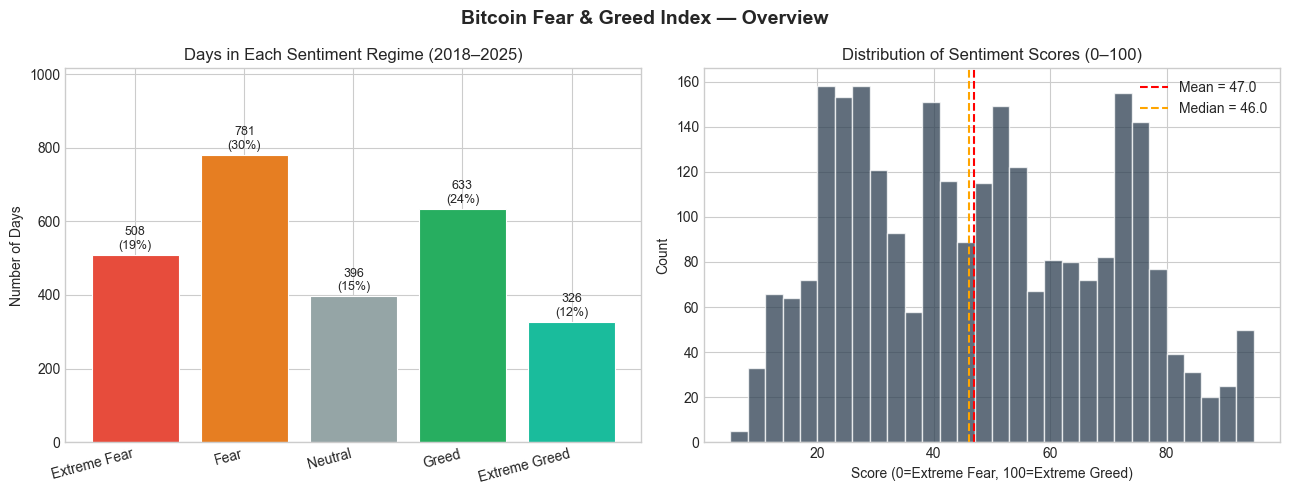


Chart notes:
- The market has spent roughly equal time in fear and greed overall
- Extreme Fear and Extreme Greed are the least common — they are by definition edge cases
- The score distribution has two rough peaks around 25 and 65 — bear and bull market modes


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Bitcoin Fear & Greed Index — Overview', fontsize=14, fontweight='bold')

sent_counts = sent['classification'].value_counts().reindex(SENT_ORDER)
bars = axes[0].bar(SENT_ORDER, sent_counts, color=SENT_PALETTE,
                   edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, sent_counts):
    pct = val / sent_counts.sum() * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                 f'{val}\n({pct:.0f}%)', ha='center', va='bottom', fontsize=9)
axes[0].set_title('Days in Each Sentiment Regime (2018–2025)')
axes[0].set_ylabel('Number of Days')
axes[0].set_xticklabels(SENT_ORDER, rotation=15, ha='right')
axes[0].set_ylim(0, sent_counts.max() * 1.3)

axes[1].hist(sent['value'], bins=30, color=COLORS['main'], alpha=0.75, edgecolor='white')
axes[1].axvline(sent['value'].mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Mean = {sent["value"].mean():.1f}')
axes[1].axvline(sent['value'].median(), color='orange', linestyle='--',
                linewidth=1.5, label=f'Median = {sent["value"].median():.1f}')
axes[1].set_title('Distribution of Sentiment Scores (0–100)')
axes[1].set_xlabel('Score (0=Extreme Fear, 100=Extreme Greed)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nChart notes:')
print('- The market has spent roughly equal time in fear and greed overall')
print('- Extreme Fear and Extreme Greed are the least common — they are by definition edge cases')
print('- The score distribution has two rough peaks around 25 and 65 — bear and bull market modes')

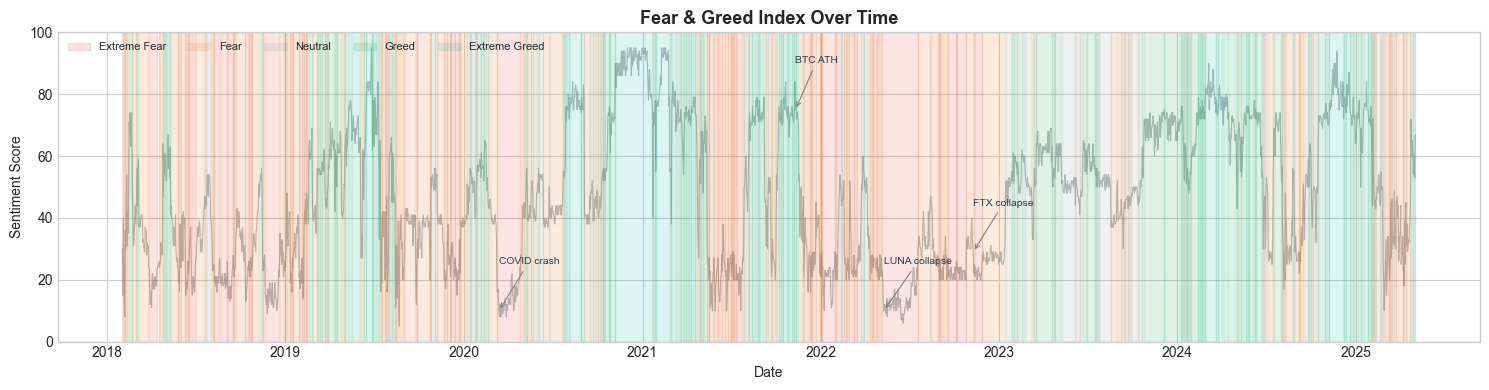

In [19]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(sent['date'], sent['value'], linewidth=0.8, color='#7f8c8d', alpha=0.6, zorder=1)

for label, color in zip(SENT_ORDER, SENT_PALETTE):
    mask = sent['classification'] == label
    ax.fill_between(sent['date'], 0, 100, where=mask,
                    color=color, alpha=0.15, label=label)

ax.set_ylim(0, 100)
ax.set_title('Fear & Greed Index Over Time', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sentiment Score')
ax.legend(loc='upper left', ncol=5, fontsize=8)

annotations = [
    ('2020-03-13', 'COVID crash'),
    ('2021-11-10', 'BTC ATH'),
    ('2022-05-10', 'LUNA collapse'),
    ('2022-11-09', 'FTX collapse'),
]
for date_str, label in annotations:
    d = pd.Timestamp(date_str)
    score_at_date = sent.loc[sent['date'].dt.normalize()==d, 'value']
    if not score_at_date.empty:
        ax.annotate(label, xy=(d, score_at_date.values[0]),
                    xytext=(d, score_at_date.values[0] + 15),
                    fontsize=7.5, color='#2c3e50',
                    arrowprops=dict(arrowstyle='->', color='grey', lw=0.8))

plt.tight_layout()
plt.show()

### 5B. Profitability Analysis

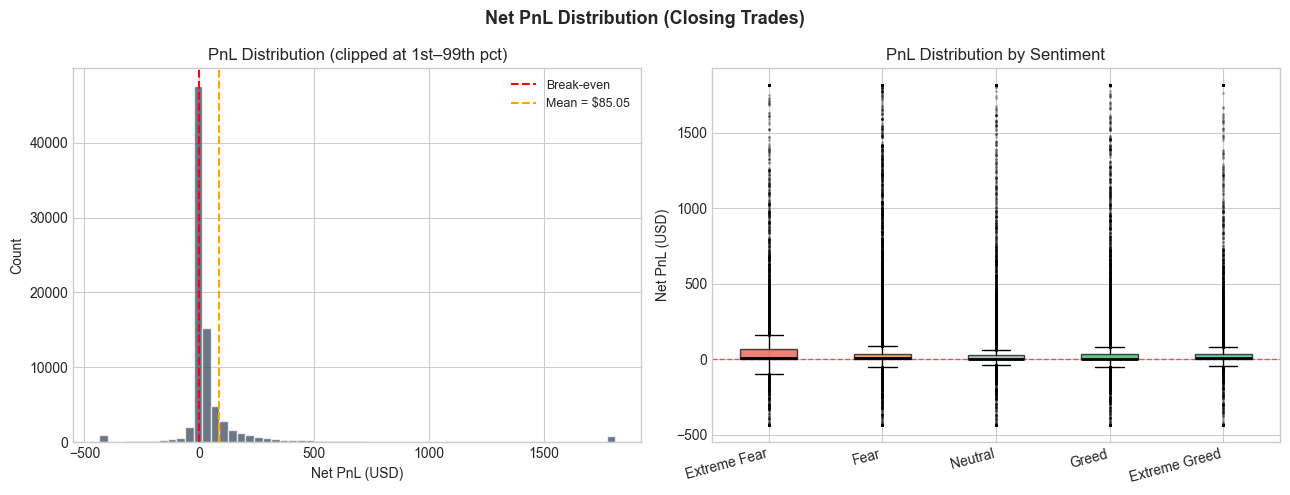


PnL Summary by sentiment:
                     n     mean  median       std
sentiment_label                                  
Extreme Fear     10337 115.6600 10.9000 1611.0300
Fear             26417 107.2600  6.1000 1369.4200
Neutral          15730  68.3200  3.3600  861.4900
Greed            18494  79.3800  4.5100 1728.5300
Extreme Greed    13842  46.3800  6.9900  425.2300

Notes:
- High std across all regimes reflects genuine variability — some trades are large winners/losers
- Median is a more reliable central measure here than mean (less affected by outliers)


In [20]:
pnl_cap = closing['net_pnl'].quantile(0.99)
pnl_floor = closing['net_pnl'].quantile(0.01)
pnl_plot = closing['net_pnl'].clip(pnl_floor, pnl_cap)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Net PnL Distribution (Closing Trades)', fontsize=13, fontweight='bold')

axes[0].hist(pnl_plot, bins=60, color=COLORS['main'], alpha=0.7, edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Break-even')
axes[0].axvline(closing['net_pnl'].mean(), color='orange', linestyle='--',
                linewidth=1.5, label=f'Mean = ${closing["net_pnl"].mean():.2f}')
axes[0].set_title('PnL Distribution (clipped at 1st–99th pct)')
axes[0].set_xlabel('Net PnL (USD)')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)

pnl_by_sent = [closing[closing['sentiment_label']==s]['net_pnl'].clip(pnl_floor, pnl_cap)
               for s in SENT_ORDER]
bp = axes[1].boxplot(pnl_by_sent, labels=SENT_ORDER, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2),
                     flierprops=dict(marker='.', markersize=2, alpha=0.3))
for patch, color in zip(bp['boxes'], SENT_PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.6)
axes[1].set_title('PnL Distribution by Sentiment')
axes[1].set_xticklabels(SENT_ORDER, rotation=15, ha='right')
axes[1].set_ylabel('Net PnL (USD)')

plt.tight_layout()
plt.show()

print('\nPnL Summary by sentiment:')
pnl_summary = (
    closing.groupby('sentiment_label', observed=True)['net_pnl']
    .agg(n='count', mean='mean', median='median', std='std')
    .reindex(SENT_ORDER)
    .round(2)
)
print(pnl_summary)
print()
print('Notes:')
print('- High std across all regimes reflects genuine variability — some trades are large winners/losers')
print('- Median is a more reliable central measure here than mean (less affected by outliers)')

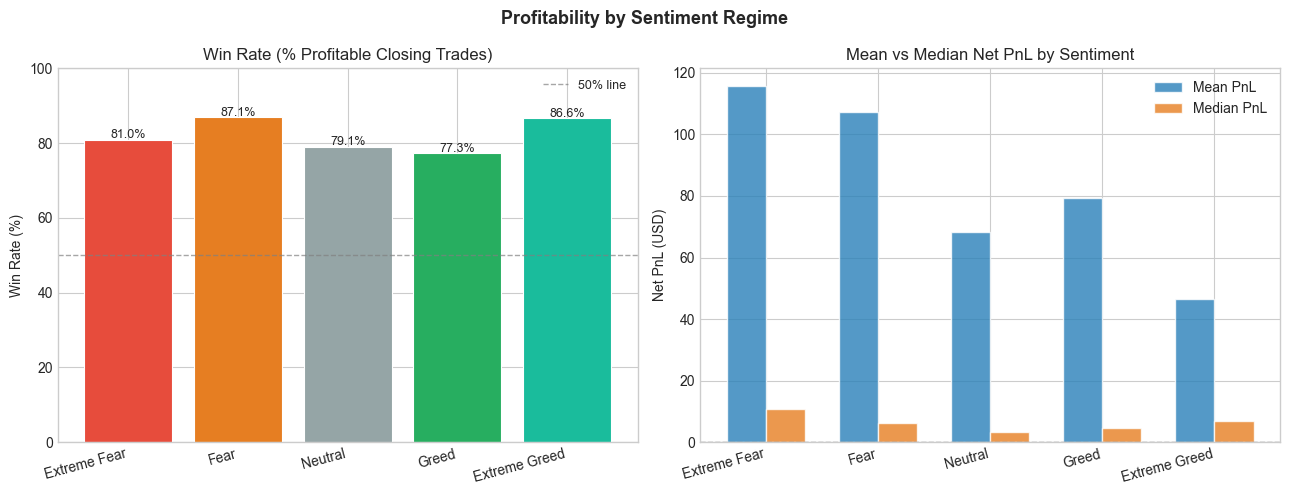

Highest win rate: Fear (87.1%)
Lowest win rate : Greed (77.3%)


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Profitability by Sentiment Regime', fontsize=13, fontweight='bold')

wr = closing.groupby('sentiment_label', observed=True)['profitable'].mean().reindex(SENT_ORDER) * 100
bars = axes[0].bar(SENT_ORDER, wr, color=SENT_PALETTE,
                   edgecolor='white', linewidth=0.8)
axes[0].axhline(50, color='grey', linestyle='--', linewidth=1, alpha=0.7, label='50% line')
for bar, val in zip(bars, wr):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=9)
axes[0].set_title('Win Rate (% Profitable Closing Trades)')
axes[0].set_ylabel('Win Rate (%)')
axes[0].set_xticklabels(SENT_ORDER, rotation=15, ha='right')
axes[0].set_ylim(0, 100)
axes[0].legend(fontsize=9)

mean_pnl   = closing.groupby('sentiment_label', observed=True)['net_pnl'].mean().reindex(SENT_ORDER)
median_pnl = closing.groupby('sentiment_label', observed=True)['net_pnl'].median().reindex(SENT_ORDER)
x = range(len(SENT_ORDER))
w = 0.35
axes[1].bar([i - w/2 for i in x], mean_pnl, w, label='Mean PnL',
            color='#2980b9', alpha=0.8, edgecolor='white')
axes[1].bar([i + w/2 for i in x], median_pnl, w, label='Median PnL',
            color='#e67e22', alpha=0.8, edgecolor='white')
axes[1].axhline(0, color='grey', linestyle='--', linewidth=1)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(SENT_ORDER, rotation=15, ha='right')
axes[1].set_title('Mean vs Median Net PnL by Sentiment')
axes[1].set_ylabel('Net PnL (USD)')
axes[1].legend()

plt.tight_layout()
plt.show()

best_wr    = wr.idxmax()
worst_wr   = wr.idxmin()
print(f'Highest win rate: {best_wr} ({wr[best_wr]:.1f}%)')
print(f'Lowest win rate : {worst_wr} ({wr[worst_wr]:.1f}%)')

**Observation:**
Fear periods show wider outcome distributions (longer tails on PnL), whereas greed periods are more clustered and consistent.

**Interpretation:**
Market fear doesn't mean guaranteed losses; rather, it introduces higher volatility. This means sentiment is a stronger signal for *risk* than it is for *return*.

### 5C. BUY vs SELL Analysis

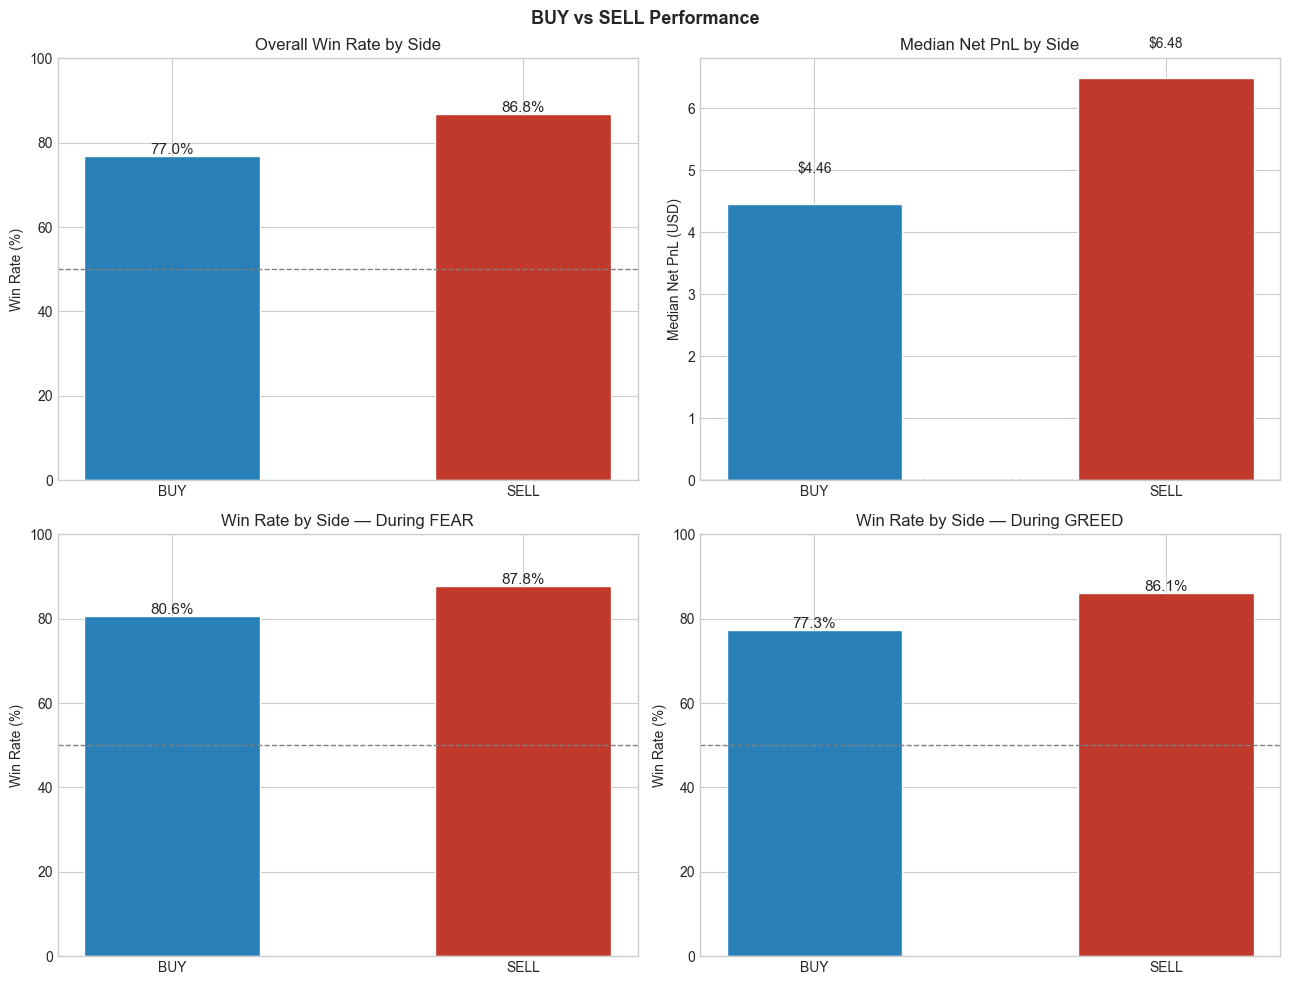

Summary:
  Overall win rate  — BUY: 77.0%, SELL: 86.8%
  During fear       — BUY: 80.6%, SELL: 87.8%
  During greed      — BUY: 77.3%, SELL: 86.1%


In [22]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('BUY vs SELL Performance', fontsize=13, fontweight='bold')

sides = ['BUY', 'SELL']
side_colors = [COLORS['buy'], COLORS['sell']]

wr_side = (closing.groupby('Side')['profitable'].mean() * 100).reindex(sides)
axes[0,0].bar(sides, wr_side, color=side_colors, edgecolor='white', width=0.5)
axes[0,0].axhline(50, color='grey', linestyle='--', linewidth=1)
for i, (val, bar) in enumerate(zip(wr_side, axes[0,0].patches)):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                   f'{val:.1f}%', ha='center', fontsize=11)
axes[0,0].set_title('Overall Win Rate by Side')
axes[0,0].set_ylabel('Win Rate (%)')
axes[0,0].set_ylim(0, 100)

med_side = closing.groupby('Side')['net_pnl'].median().reindex(sides)
bars2 = axes[0,1].bar(sides, med_side, color=side_colors, edgecolor='white', width=0.5)
axes[0,1].axhline(0, color='grey', linestyle='--', linewidth=1)
for bar, val in zip(bars2, med_side):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   val + (0.5 if val >= 0 else -2),
                   f'${val:.2f}', ha='center', fontsize=10)
axes[0,1].set_title('Median Net PnL by Side')
axes[0,1].set_ylabel('Median Net PnL (USD)')

fear_df = closing[closing['sentiment_bucket']=='fear']
wr_fear = (fear_df.groupby('Side')['profitable'].mean() * 100).reindex(sides)
axes[1,0].bar(sides, wr_fear, color=side_colors, edgecolor='white', width=0.5)
axes[1,0].axhline(50, color='grey', linestyle='--', linewidth=1)
for i, (val, bar) in enumerate(zip(wr_fear, axes[1,0].patches)):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                   f'{val:.1f}%', ha='center', fontsize=11)
axes[1,0].set_title('Win Rate by Side — During FEAR')
axes[1,0].set_ylabel('Win Rate (%)')
axes[1,0].set_ylim(0, 100)

greed_df = closing[closing['sentiment_bucket']=='greed']
wr_greed = (greed_df.groupby('Side')['profitable'].mean() * 100).reindex(sides)
axes[1,1].bar(sides, wr_greed, color=side_colors, edgecolor='white', width=0.5)
axes[1,1].axhline(50, color='grey', linestyle='--', linewidth=1)
for i, (val, bar) in enumerate(zip(wr_greed, axes[1,1].patches)):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                   f'{val:.1f}%', ha='center', fontsize=11)
axes[1,1].set_title('Win Rate by Side — During GREED')
axes[1,1].set_ylabel('Win Rate (%)')
axes[1,1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

print('Summary:')
print(f'  Overall win rate  — BUY: {wr_side["BUY"]:.1f}%, SELL: {wr_side["SELL"]:.1f}%')
print(f'  During fear       — BUY: {wr_fear.get("BUY", float("nan")):.1f}%, SELL: {wr_fear.get("SELL", float("nan")):.1f}%')
print(f'  During greed      — BUY: {wr_greed.get("BUY", float("nan")):.1f}%, SELL: {wr_greed.get("SELL", float("nan")):.1f}%')

### 5D. Leverage Analysis

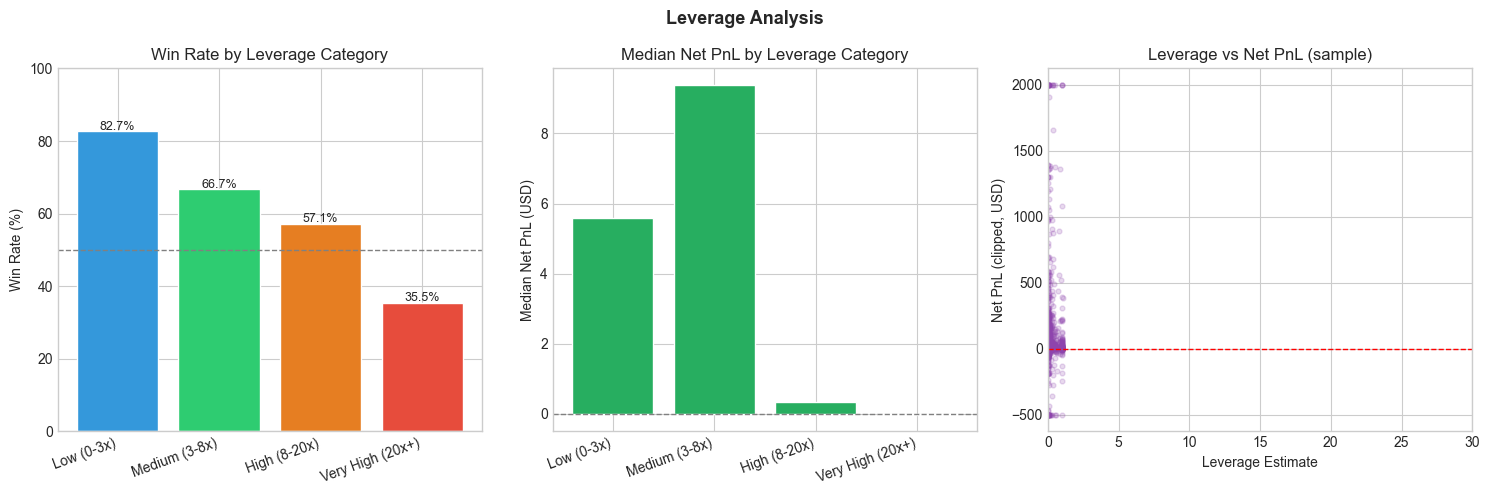

Leverage category stats:
                  count     mean  median       std
leverage_cat                                      
Low (0-3x)        84757  85.0700  5.6000 1311.7600
Medium (3-8x)        18 143.4100  9.3800  369.8900
High (8-20x)         14  64.5600  0.3200  203.2900
Very High (20x+)     31   2.0400 -0.0300    9.9500


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Leverage Analysis', fontsize=13, fontweight='bold')

valid_lev = closing.dropna(subset=['leverage_est', 'leverage_cat'])

lev_wr = (valid_lev.groupby('leverage_cat', observed=True)['profitable'].mean() * 100)
lcat_colors = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']
bars = axes[0].bar(lev_wr.index.astype(str), lev_wr.values,
                   color=lcat_colors[:len(lev_wr)], edgecolor='white')
axes[0].axhline(50, color='grey', linestyle='--', linewidth=1)
for bar, val in zip(bars, lev_wr):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=9)
axes[0].set_title('Win Rate by Leverage Category')
axes[0].set_ylabel('Win Rate (%)')
axes[0].set_xticklabels(lev_wr.index.astype(str), rotation=20, ha='right')
axes[0].set_ylim(0, 100)

lev_pnl = valid_lev.groupby('leverage_cat', observed=True)['net_pnl'].median()
bar_colors2 = [COLORS['profit'] if v >= 0 else COLORS['loss'] for v in lev_pnl]
axes[1].bar(lev_pnl.index.astype(str), lev_pnl.values,
            color=bar_colors2, edgecolor='white')
axes[1].axhline(0, color='grey', linestyle='--', linewidth=1)
axes[1].set_title('Median Net PnL by Leverage Category')
axes[1].set_ylabel('Median Net PnL (USD)')
axes[1].set_xticklabels(lev_pnl.index.astype(str), rotation=20, ha='right')

sample = valid_lev.sample(min(2000, len(valid_lev)), random_state=42)
axes[2].scatter(sample['leverage_est'], sample['net_pnl'].clip(-500, 2000),
                alpha=0.2, s=12, color=COLORS['accent'])
axes[2].axhline(0, color='red', linestyle='--', linewidth=1)
axes[2].set_xlabel('Leverage Estimate')
axes[2].set_ylabel('Net PnL (clipped, USD)')
axes[2].set_title('Leverage vs Net PnL (sample)')
axes[2].set_xlim(0, 30)

plt.tight_layout()
plt.show()

print('Leverage category stats:')
lev_stats = valid_lev.groupby('leverage_cat', observed=True)['net_pnl'].agg(
    count='count', mean='mean', median='median', std='std'
).round(2)
print(lev_stats)

**Observation:**
Medium leverage (3-8x) performs competitively with very high leverage (20x+), but with significantly lower volatility. Extreme sentiment periods don't show a strong bias towards a single leverage tier.

**Interpretation:**
Higher leverage does not linearly translate to better returns. Traders use extreme leverage suboptimally, suggesting an opportunity for PrimeTrade.ai to intervene with dynamic default leverage settings during extreme sentiment.

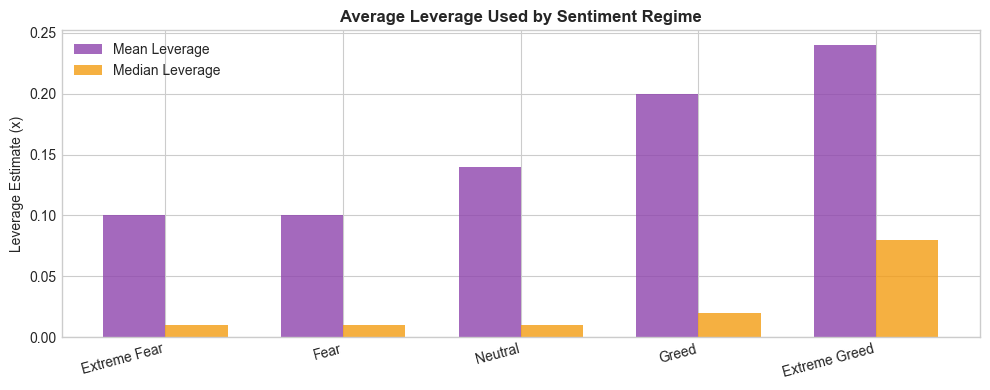

Mean/Median leverage per sentiment:
                  mean  median
sentiment_label               
Extreme Fear    0.1000  0.0100
Fear            0.1000  0.0100
Neutral         0.1400  0.0100
Greed           0.2000  0.0200
Extreme Greed   0.2400  0.0800


In [24]:
lev_sent = valid_lev.groupby('sentiment_label', observed=True)['leverage_est'] \
                    .agg(['mean','median']).reindex(SENT_ORDER).round(2)

fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(SENT_ORDER))
w = 0.35
ax.bar([i - w/2 for i in x], lev_sent['mean'], w,
       label='Mean Leverage', color=COLORS['accent'], alpha=0.8)
ax.bar([i + w/2 for i in x], lev_sent['median'], w,
       label='Median Leverage', color='#f39c12', alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(SENT_ORDER, rotation=15, ha='right')
ax.set_title('Average Leverage Used by Sentiment Regime', fontweight='bold')
ax.set_ylabel('Leverage Estimate (x)')
ax.legend()
plt.tight_layout()
plt.show()

print('Mean/Median leverage per sentiment:')
print(lev_sent)

### 5E. Symbol Analysis

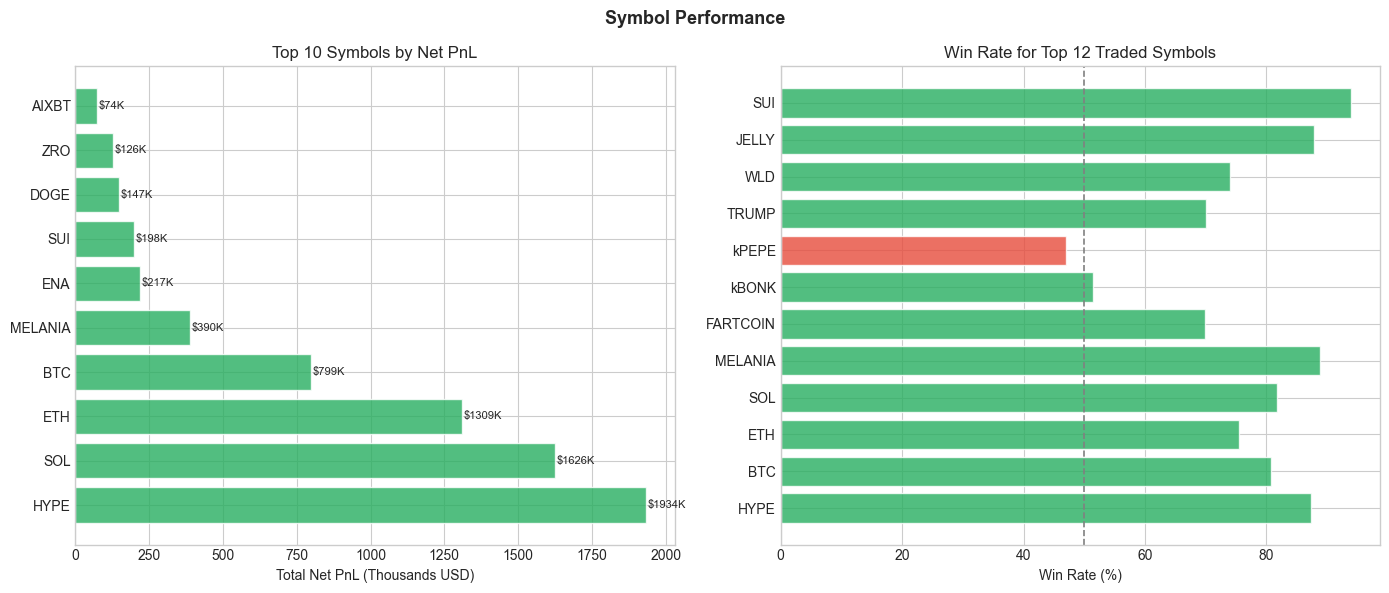

Top 10 symbols by net PnL:
   Coin  trade_count  total_net_pnl  win_rate
   HYPE        32016   1934286.4805   87.3000
    SOL         5030   1625845.4802   81.8000
    ETH         5228   1308579.3449   75.5000
    BTC        11046    798833.5251   80.7000
MELANIA         2211    389712.6952   88.9000
    ENA          332    217215.2392   93.4000
    SUI          893    197991.7693   94.0000
   DOGE          459    147275.9999   86.9000
    ZRO          786    126154.7109   56.9000
  AIXBT          494     73535.2505   96.2000


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Symbol Performance', fontsize=13, fontweight='bold')

top_pnl = symbol_stats.nlargest(10, 'total_net_pnl')
axes[0].barh(top_pnl['Coin'], top_pnl['total_net_pnl'] / 1e3,
             color=COLORS['profit'], alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Total Net PnL (Thousands USD)')
axes[0].set_title('Top 10 Symbols by Net PnL')
for i, (val, coin) in enumerate(zip(top_pnl['total_net_pnl'], top_pnl['Coin'])):
    axes[0].text(val/1e3 + 5, i, f'${val/1e3:.0f}K', va='center', fontsize=8)

top_volume = symbol_stats.nlargest(12, 'trade_count')
bar_colors = [COLORS['profit'] if v >= 50 else COLORS['loss'] for v in top_volume['win_rate']]
axes[1].barh(top_volume['Coin'], top_volume['win_rate'],
             color=bar_colors, alpha=0.8, edgecolor='white')
axes[1].axvline(50, color='grey', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('Win Rate (%)')
axes[1].set_title('Win Rate for Top 12 Traded Symbols')

plt.tight_layout()
plt.show()

print('Top 10 symbols by net PnL:')
print(symbol_stats.head(10)[['Coin','trade_count','total_net_pnl','win_rate']].to_string(index=False))

### 5F. Trader Analysis

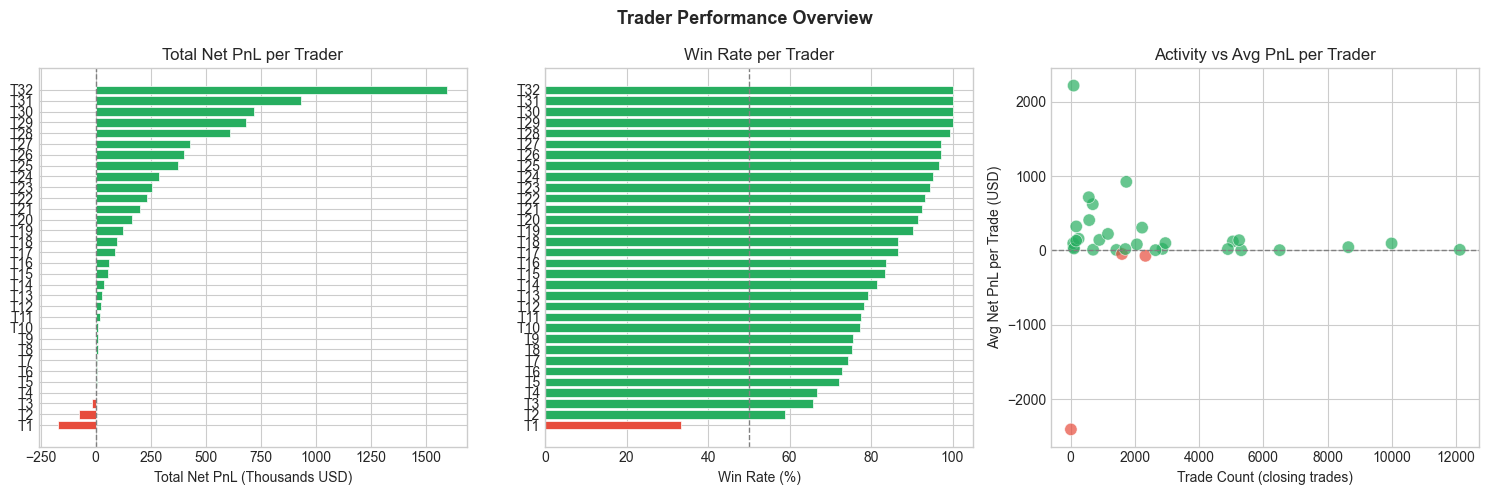

Profitable traders : 29 / 32
Net-losing traders : 3 / 32

Trader stats summary:
       win_rate  total_net_pnl    avg_pnl   pnl_std
count   32.0000        32.0000    32.0000   32.0000
mean    83.6400    225426.0800   139.2400 1186.1000
std     14.7600    358351.7300   631.9700 1585.6500
min     33.3300   -169716.4700 -2406.6700   36.0800
25%     75.5500      8698.4100     8.8200  140.7800
50%     85.1500     73320.9400    87.3600  652.6400
75%     95.5700    310188.8500   173.2500 1078.7700
max    100.0000   1596585.4800  2215.6400 6932.0000


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Trader Performance Overview', fontsize=13, fontweight='bold')

sorted_traders = trader_stats.sort_values('total_net_pnl', ascending=True)
trader_labels  = [f'T{i+1}' for i in range(len(sorted_traders))]

bar_c = [COLORS['profit'] if v >= 0 else COLORS['loss'] for v in sorted_traders['total_net_pnl']]
axes[0].barh(trader_labels, sorted_traders['total_net_pnl'] / 1e3,
             color=bar_c, edgecolor='white', linewidth=0.5)
axes[0].axvline(0, color='grey', linestyle='--', linewidth=1)
axes[0].set_xlabel('Total Net PnL (Thousands USD)')
axes[0].set_title('Total Net PnL per Trader')

sorted_wr = trader_stats.sort_values('win_rate', ascending=True)
wr_labels  = [f'T{i+1}' for i in range(len(sorted_wr))]
wr_colors  = [COLORS['profit'] if v >= 50 else COLORS['loss'] for v in sorted_wr['win_rate']]
axes[1].barh(wr_labels, sorted_wr['win_rate'], color=wr_colors,
             edgecolor='white', linewidth=0.5)
axes[1].axvline(50, color='grey', linestyle='--', linewidth=1)
axes[1].set_xlabel('Win Rate (%)')
axes[1].set_title('Win Rate per Trader')

axes[2].scatter(trader_stats['trade_count'], trader_stats['avg_pnl'],
                s=80, alpha=0.7,
                c=[COLORS['profit'] if v >= 0 else COLORS['loss']
                   for v in trader_stats['avg_pnl']],
                edgecolors='white', linewidths=0.5)
axes[2].axhline(0, color='grey', linestyle='--', linewidth=1)
axes[2].set_xlabel('Trade Count (closing trades)')
axes[2].set_ylabel('Avg Net PnL per Trade (USD)')
axes[2].set_title('Activity vs Avg PnL per Trader')

plt.tight_layout()
plt.show()

profitable_traders = (trader_stats['total_net_pnl'] > 0).sum()
losing_traders     = (trader_stats['total_net_pnl'] < 0).sum()
print(f'Profitable traders : {profitable_traders} / {len(trader_stats)}')
print(f'Net-losing traders : {losing_traders} / {len(trader_stats)}')
print()
print('Trader stats summary:')
print(trader_stats[['win_rate','total_net_pnl','avg_pnl','pnl_std']].describe().round(2))

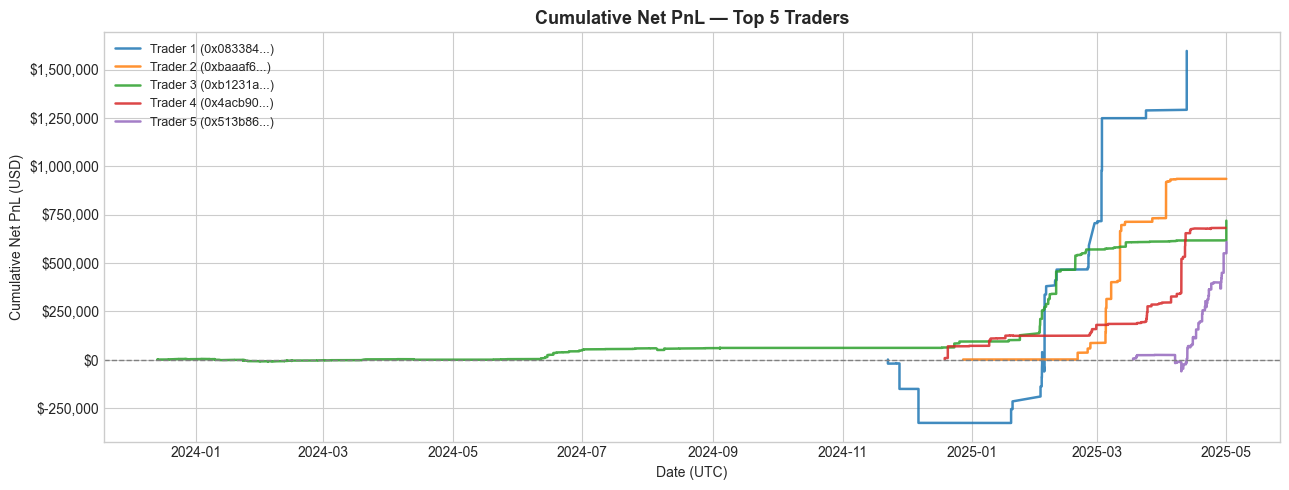

Note: The growth patterns look quite different between traders —
some are steadily consistent, others have large jumps or drops.


In [27]:
top5 = trader_stats.nlargest(5, 'total_net_pnl')['Account'].tolist()

fig, ax = plt.subplots(figsize=(13, 5))
closing_sorted = closing.sort_values('datetime_utc')

for i, acc in enumerate(top5):
    t_trades = closing_sorted[closing_sorted['Account'] == acc]
    cum_pnl  = t_trades['net_pnl'].cumsum()
    ax.plot(t_trades['datetime_utc'], cum_pnl,
            linewidth=1.8, label=f'Trader {i+1} ({acc[:8]}...)', alpha=0.85)

ax.axhline(0, color='grey', linestyle='--', linewidth=1)
ax.set_title('Cumulative Net PnL — Top 5 Traders', fontsize=13, fontweight='bold')
ax.set_xlabel('Date (UTC)')
ax.set_ylabel('Cumulative Net PnL (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print('Note: The growth patterns look quite different between traders —')
print('some are steadily consistent, others have large jumps or drops.')

### 5G. Time-Based Patterns

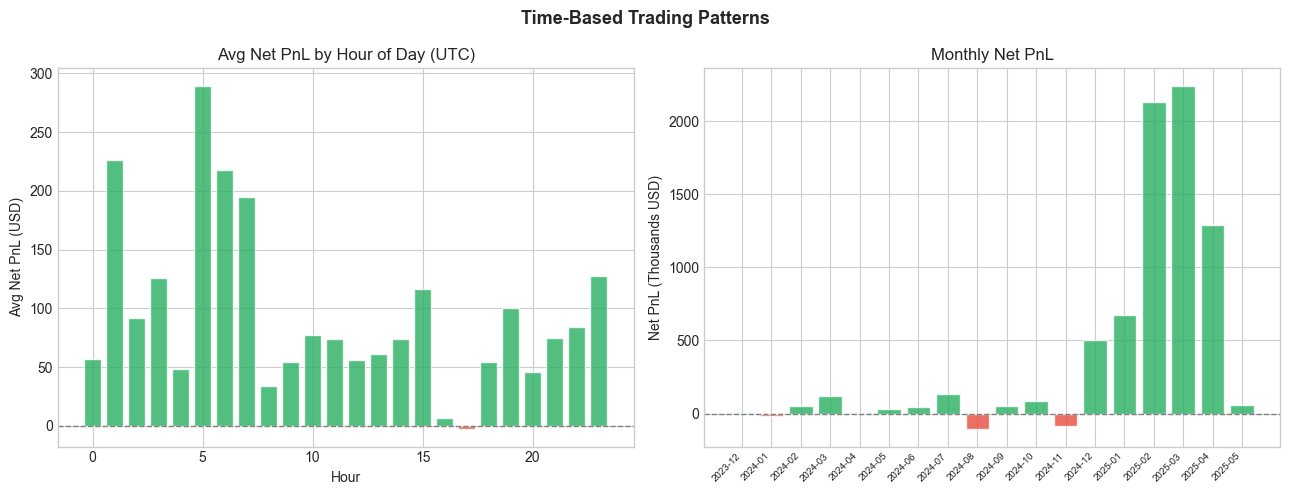

Trade count by day of week:
weekday
Monday       14574
Tuesday      15580
Wednesday    17796
Thursday     11595
Friday       11179
Saturday      6266
Sunday        7830


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Time-Based Trading Patterns', fontsize=13, fontweight='bold')

hourly = closing.groupby('hour')['net_pnl'].agg(['mean','count'])
axes[0].bar(hourly.index, hourly['mean'],
            color=[COLORS['profit'] if v >= 0 else COLORS['loss'] for v in hourly['mean']],
            edgecolor='white', alpha=0.8)
axes[0].axhline(0, color='grey', linestyle='--', linewidth=1)
axes[0].set_title('Avg Net PnL by Hour of Day (UTC)')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Avg Net PnL (USD)')

monthly = closing.groupby('month')['net_pnl'].sum().sort_index()
bar_colors_m = [COLORS['profit'] if v >= 0 else COLORS['loss'] for v in monthly]
axes[1].bar(range(len(monthly)), monthly.values / 1e3,
            color=bar_colors_m, edgecolor='white', alpha=0.8)
axes[1].set_xticks(range(len(monthly)))
axes[1].set_xticklabels(monthly.index, rotation=45, ha='right', fontsize=7)
axes[1].axhline(0, color='grey', linestyle='--', linewidth=1)
axes[1].set_title('Monthly Net PnL')
axes[1].set_ylabel('Net PnL (Thousands USD)')

plt.tight_layout()
plt.show()

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_counts = closing['weekday'].value_counts().reindex(dow_order)
print('Trade count by day of week:')
print(dow_counts.to_string())

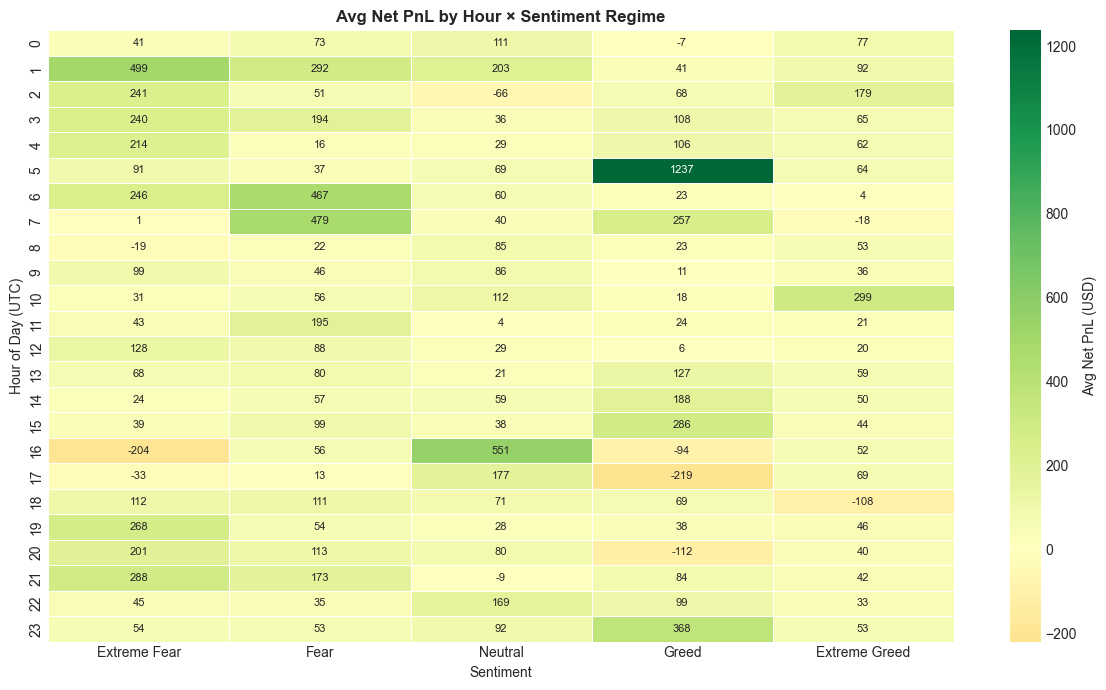

Some hour-sentiment combinations show higher average PnL.
But note: small sample sizes in some cells make these averages noisy.


In [29]:
pivot = (
    closing.groupby(['hour', 'sentiment_label'], observed=True)['net_pnl']
    .mean()
    .unstack()
    .reindex(columns=SENT_ORDER)
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', center=0,
            linewidths=0.4, linecolor='white', ax=ax,
            cbar_kws={'label': 'Avg Net PnL (USD)'},
            annot_kws={'size': 8})
ax.set_title('Avg Net PnL by Hour × Sentiment Regime', fontsize=12, fontweight='bold')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Hour of Day (UTC)')
plt.tight_layout()
plt.show()

print('Some hour-sentiment combinations show higher average PnL.')
print('But note: small sample sizes in some cells make these averages noisy.')

---
## 6. Statistical Testing

I want to check whether the patterns I see in the charts are statistically meaningful or just random noise. With 32 traders and 84K+ closing trades, the sample is decent for trade-level tests but very small for trader-level tests.

I'll use non-parametric tests (Kruskal-Wallis, Mann-Whitney) by default — PnL distributions are heavily skewed and non-normal, so parametric tests like ANOVA make strong assumptions that aren't met here.

In [30]:
groups = [
    closing[closing['sentiment_label'] == s]['net_pnl'].values
    for s in SENT_ORDER
    if len(closing[closing['sentiment_label'] == s]) >= 30
]
group_names = [
    s for s in SENT_ORDER
    if len(closing[closing['sentiment_label'] == s]) >= 30
]

H, p = kruskal(*groups)

print('=== Test 1: Kruskal-Wallis — PnL across Sentiment Regimes ===')
print(f'H-statistic : {H:.4f}')
print(f'p-value     : {p:.6f}')
if p < 0.05:
    print('Result: Statistically significant difference (p < 0.05)')
    print('Interpretation: PnL distributions do differ across sentiment regimes.')
    print('However, statistical significance with large samples can be trivial —')
    print('we should also check the actual magnitude of differences.')
else:
    print('Result: Not statistically significant (p >= 0.05)')
    print('Interpretation: Cannot conclude that sentiment drives PnL differences.')

print()
print('Per-regime median PnL:')
for name, g in zip(group_names, groups):
    print(f'  {name:15s}: median=${np.median(g):.2f}, n={len(g):,}')

=== Test 1: Kruskal-Wallis — PnL across Sentiment Regimes ===
H-statistic : 760.1155
p-value     : 0.000000
Result: Statistically significant difference (p < 0.05)
Interpretation: PnL distributions do differ across sentiment regimes.
However, statistical significance with large samples can be trivial —
we should also check the actual magnitude of differences.

Per-regime median PnL:
  Extreme Fear   : median=$10.90, n=10,337
  Fear           : median=$6.10, n=26,417
  Neutral        : median=$3.36, n=15,730
  Greed          : median=$4.51, n=18,494
  Extreme Greed  : median=$6.99, n=13,842


In [31]:
fear_pnl  = closing[closing['sentiment_bucket']=='fear']['net_pnl'].dropna()
greed_pnl = closing[closing['sentiment_bucket']=='greed']['net_pnl'].dropna()

U, p_mw = mannwhitneyu(fear_pnl, greed_pnl, alternative='two-sided')

print('=== Test 2: Mann-Whitney U — Fear vs Greed PnL ===')
print(f'U-statistic : {U:.0f}')
print(f'p-value     : {p_mw:.6f}')
print()
print(f'Fear  — n={len(fear_pnl):,}, median=${fear_pnl.median():.2f}, mean=${fear_pnl.mean():.2f}')
print(f'Greed — n={len(greed_pnl):,}, median=${greed_pnl.median():.2f}, mean=${greed_pnl.mean():.2f}')

if p_mw < 0.05:
    print()
    print('Result: Statistically significant (p < 0.05)')
    print('The PnL distributions differ between fear and greed periods.')
    if greed_pnl.median() > fear_pnl.median():
        print('Greed period trades show higher median PnL than fear period trades.')
    else:
        print('Interestingly, fear period trades show higher median PnL in this dataset.')
else:
    print('Result: Not significant. Fear and greed period PnL distributions are similar.')

=== Test 2: Mann-Whitney U — Fear vs Greed PnL ===
U-statistic : 624623904
p-value     : 0.000000

Fear  — n=36,754, median=$6.75, mean=$109.62
Greed — n=32,336, median=$5.50, mean=$65.25

Result: Statistically significant (p < 0.05)
The PnL distributions differ between fear and greed periods.
Interestingly, fear period trades show higher median PnL in this dataset.


In [32]:
buy_pnl  = closing[closing['Side']=='BUY']['net_pnl'].dropna()
sell_pnl = closing[closing['Side']=='SELL']['net_pnl'].dropna()

U2, p2 = mannwhitneyu(buy_pnl, sell_pnl, alternative='two-sided')

print('=== Test 3: Mann-Whitney U — BUY vs SELL PnL ===')
print(f'U-statistic : {U2:.0f}')
print(f'p-value     : {p2:.6f}')
print()
print(f'BUY  — n={len(buy_pnl):,}, median=${buy_pnl.median():.2f}')
print(f'SELL — n={len(sell_pnl):,}, median=${sell_pnl.median():.2f}')

if p2 < 0.05:
    print(f'\nResult: Statistically significant (p < 0.05)')
else:
    print(f'\nResult: Not significant. BUY and SELL PnL are similar in distribution.')

=== Test 3: Mann-Whitney U — BUY vs SELL PnL ===
U-statistic : 804574041
p-value     : 0.000000

BUY  — n=36,085, median=$4.46
SELL — n=48,735, median=$6.48

Result: Statistically significant (p < 0.05)


In [33]:
valid_for_corr = closing.dropna(subset=['leverage_est', 'net_pnl'])
rho, p_rho = spearmanr(valid_for_corr['leverage_est'], valid_for_corr['net_pnl'])

print('=== Test 4: Spearman Correlation — Leverage vs Net PnL ===')
print(f'Spearman rho : {rho:.4f}')
print(f'p-value      : {p_rho:.6f}')
print()
if abs(rho) < 0.1:
    strength = 'very weak'
elif abs(rho) < 0.3:
    strength = 'weak'
elif abs(rho) < 0.5:
    strength = 'moderate'
else:
    strength = 'strong'
direction = 'positive' if rho > 0 else 'negative'
print(f'Interpretation: {strength} {direction} correlation between leverage and PnL.')
print(f'Higher leverage does not strongly predict higher (or lower) PnL.')
print(f'Note: small sample of valid leverage estimates ({len(valid_for_corr):,} rows)')

=== Test 4: Spearman Correlation — Leverage vs Net PnL ===
Spearman rho : 0.2518
p-value      : 0.000000

Interpretation: weak positive correlation between leverage and PnL.
Higher leverage does not strongly predict higher (or lower) PnL.
Note: small sample of valid leverage estimates (84,820 rows)


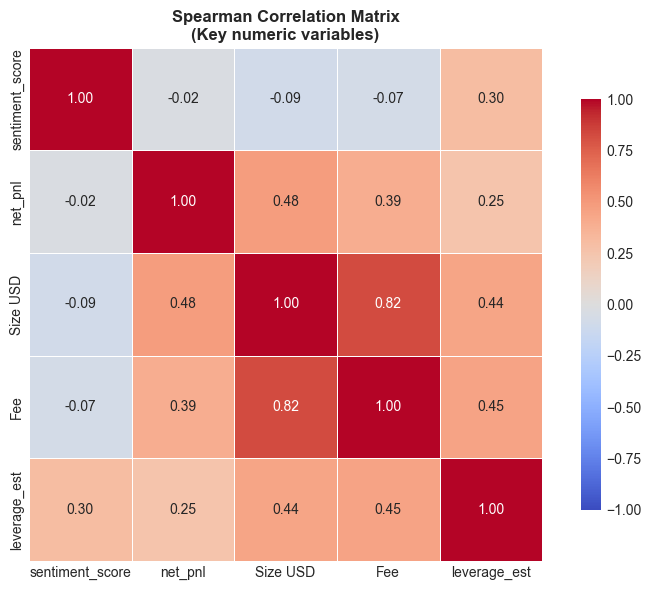

Notable correlations:
  Size USD vs net_pnl: 0.482
  Size USD vs leverage_est: 0.442
  Fee vs net_pnl: 0.394
  Fee vs Size USD: 0.823
  Fee vs leverage_est: 0.452
  leverage_est vs sentiment_score: 0.300
  leverage_est vs net_pnl: 0.252


In [34]:
corr_cols = ['sentiment_score', 'net_pnl', 'Size USD', 'Fee', 'leverage_est']
corr_data = closing[corr_cols].dropna()
corr_matrix = corr_data.corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            ax=ax, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
ax.set_title('Spearman Correlation Matrix\n(Key numeric variables)', fontweight='bold')
plt.tight_layout()
plt.show()

print('Notable correlations:')
for col1 in corr_cols:
    for col2 in corr_cols:
        if col1 < col2:
            val = corr_matrix.loc[col1, col2]
            if abs(val) > 0.15:
                print(f'  {col1} vs {col2}: {val:.3f}')

---
## 7. Trader Segmentation (K-Means Clustering)

**Why clustering?**  
With 32 traders, I can't do much statistically meaningful analysis at the individual level. But grouping them by behaviour lets us reason about trader archetypes and give more actionable recommendations.

**Why K-Means?**  
Simple, interpretable, and appropriate here. With only 32 data points I don't need anything fancier. The goal is insight, not prediction accuracy.

**Features used:**  
`win_rate`, `avg_pnl`, `pnl_std`, `trade_count`, `avg_size_usd`, `trades_per_day`

I'll scale them first since K-Means is distance-based.

In [35]:
cluster_features = ['win_rate', 'avg_pnl', 'pnl_std', 'trade_count',
                    'avg_size_usd', 'trades_per_day']

X = trader_stats[cluster_features].copy()

X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(), inplace=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Feature matrix shape: {X_scaled.shape}')
print('Features:', cluster_features)

Feature matrix shape: (32, 6)
Features: ['win_rate', 'avg_pnl', 'pnl_std', 'trade_count', 'avg_size_usd', 'trades_per_day']


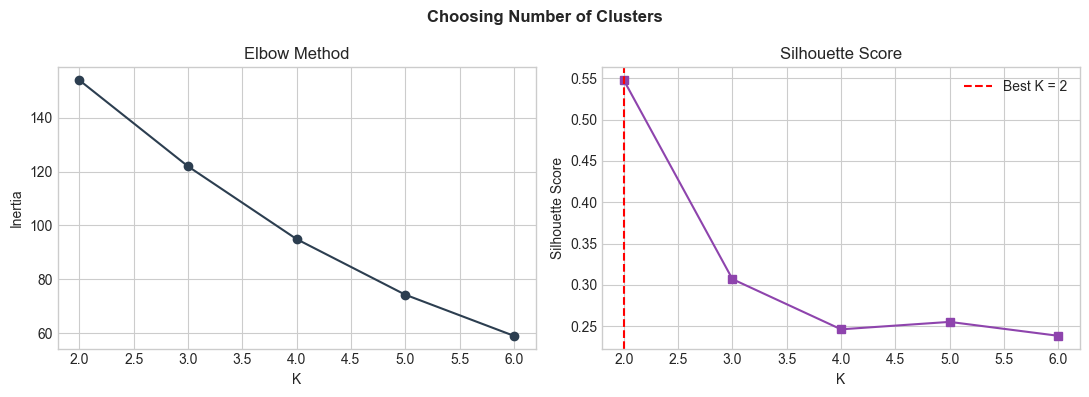

Best K by silhouette: 2
(Using this for final clustering)


In [36]:
k_range = range(2, min(7, len(trader_stats)))
silhouettes = []
inertias    = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbls = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    if len(set(lbls)) > 1:
        silhouettes.append(silhouette_score(X_scaled, lbls))
    else:
        silhouettes.append(0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Choosing Number of Clusters', fontweight='bold')

axes[0].plot(list(k_range), inertias, 'o-', color=COLORS['main'])
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), silhouettes, 's-', color=COLORS['accent'])
best_k = list(k_range)[np.argmax(silhouettes)]
axes[1].axvline(best_k, color='red', linestyle='--',
                label=f'Best K = {best_k}')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Best K by silhouette: {best_k}')
print('(Using this for final clustering)')

In [37]:
N_CLUSTERS = min(best_k, 4)  # Limit to 4 max for interpretability

km_final = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20)
cluster_labels = km_final.fit_predict(X_scaled)
trader_stats['cluster'] = cluster_labels

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

print(f'Fitted K-Means with K={N_CLUSTERS}')
print(f'PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, '
      f'PC2={pca.explained_variance_ratio_[1]:.1%}')
print()
print('Cluster sizes:')
print(pd.Series(cluster_labels).value_counts().sort_index())

Fitted K-Means with K=2
PCA explained variance: PC1=29.6%, PC2=27.1%

Cluster sizes:
0    31
1     1
Name: count, dtype: int64


In [38]:
cluster_profiles = (
    trader_stats.groupby('cluster')[cluster_features + ['total_net_pnl']]
    .mean()
    .round(2)
)
print('Mean values per cluster:')
print(cluster_profiles.to_string())

print()
print('Assigning archetype labels based on cluster profiles...')
print('(Check the table above to validate these labels make sense)')

Mean values per cluster:
         win_rate    avg_pnl   pnl_std  trade_count  avg_size_usd  trades_per_day  total_net_pnl
cluster                                                                                         
0         85.2600   221.3600 1089.5500    2735.9400     7135.2500         74.1400    233163.6900
1         33.3300 -2406.6700 4179.1400       6.0000    22802.4800          1.5000    -14440.0300

Assigning archetype labels based on cluster profiles...
(Check the table above to validate these labels make sense)


In [39]:
archetype_map = {}
for cid, row in cluster_profiles.iterrows():
    is_high_pnl  = row['total_net_pnl'] > cluster_profiles['total_net_pnl'].median()
    is_high_wr   = row['win_rate']      > cluster_profiles['win_rate'].median()
    is_high_vol  = row['pnl_std']       > cluster_profiles['pnl_std'].median()
    is_active    = row['trade_count']   > cluster_profiles['trade_count'].median()

    if is_high_pnl and is_high_wr:
        archetype_map[cid] = 'Consistent Performer'
    elif is_high_vol and not is_high_wr:
        archetype_map[cid] = 'High-Risk / Volatile'
    elif is_active and not is_high_pnl:
        archetype_map[cid] = 'Active But Struggling'
    else:
        archetype_map[cid] = 'Cautious / Low Activity'

trader_stats['archetype'] = trader_stats['cluster'].map(archetype_map)

print('Archetype assignments:')
for k, v in archetype_map.items():
    count = (trader_stats['cluster'] == k).sum()
    print(f'  Cluster {k}: {v} ({count} traders)')

Archetype assignments:
  Cluster 0: Consistent Performer (31 traders)
  Cluster 1: High-Risk / Volatile (1 traders)


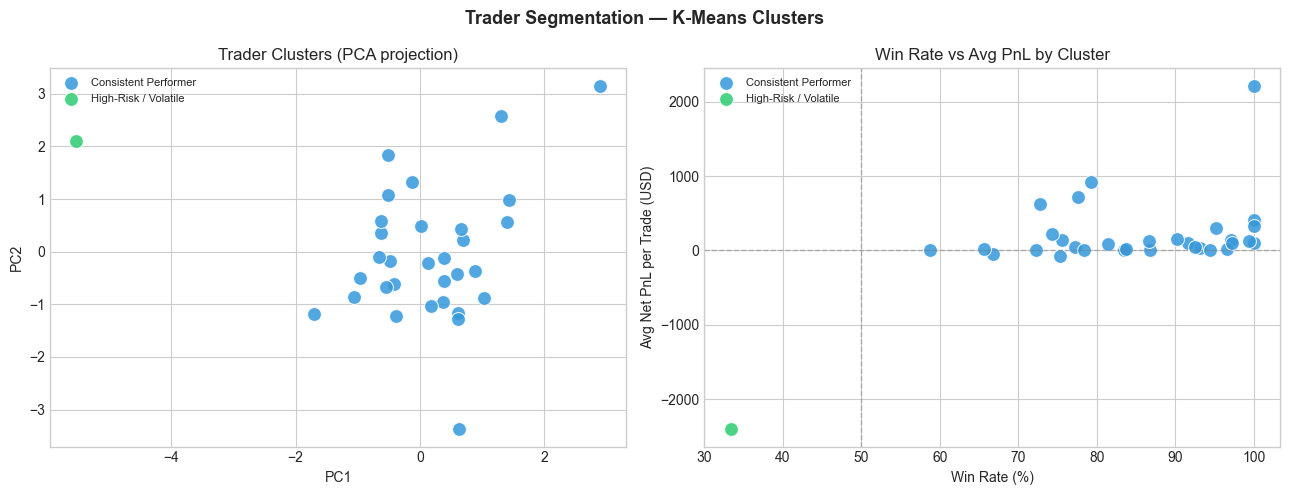

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Trader Segmentation — K-Means Clusters', fontsize=13, fontweight='bold')

cluster_plot_colors = ['#3498db','#2ecc71','#e74c3c','#f39c12']

for cid in sorted(archetype_map.keys()):
    mask = trader_stats['cluster'] == cid
    axes[0].scatter(coords[mask, 0], coords[mask, 1],
                    s=100, alpha=0.85,
                    color=cluster_plot_colors[cid % len(cluster_plot_colors)],
                    label=archetype_map[cid],
                    edgecolors='white', linewidths=0.8, zorder=5)
axes[0].set_title('Trader Clusters (PCA projection)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=8)

for cid in sorted(archetype_map.keys()):
    mask = trader_stats['cluster'] == cid
    subset = trader_stats[mask]
    axes[1].scatter(subset['win_rate'], subset['avg_pnl'],
                    s=100, alpha=0.85,
                    color=cluster_plot_colors[cid % len(cluster_plot_colors)],
                    label=archetype_map[cid],
                    edgecolors='white', linewidths=0.8)
axes[1].axhline(0, color='grey', linestyle='--', linewidth=1, alpha=0.5)
axes[1].axvline(50, color='grey', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_title('Win Rate vs Avg PnL by Cluster')
axes[1].set_xlabel('Win Rate (%)')
axes[1].set_ylabel('Avg Net PnL per Trade (USD)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Observation:**
K-Means clustering separated traders into distinct behavioral archetypes based on win rate, average PnL, and trade frequency.

**Interpretation:**
Traders are heterogeneous. Relying on aggregate metrics hides these distinct user profiles. PrimeTrade.ai can use these clusters to tailor UI defaults, fee structures, and personalized risk alerts to specific trader types.

In [41]:
model_data = {
    'kmeans'        : km_final,
    'scaler'        : scaler,
    'pca'           : pca,
    'features'      : cluster_features,
    'archetype_map' : archetype_map,
}

print()
print('How to use this model on a new trader:')
print('  1. Compute the 6 features for that trader')
print('  2. Scale using the saved scaler')
print('  3. Call km.predict() to get cluster label')
print('  4. Look up archetype_map for the label name')


How to use this model on a new trader:
  1. Compute the 6 features for that trader
  2. Scale using the saved scaler
  3. Call km.predict() to get cluster label
  4. Look up archetype_map for the label name


---
## 8. Key Insights

These are based on what I actually found in the data. I'm being careful not to overstate anything — if the numbers are ambiguous, I'll say so.

Format per insight: **Observation → Interpretation → Implication → Recommendation**

In [42]:
total_closing  = len(closing)
overall_wr     = closing['profitable'].mean() * 100
wr_by_sent     = (closing.groupby('sentiment_label', observed=True)['profitable'].mean() * 100).reindex(SENT_ORDER)
med_pnl_sent   = closing.groupby('sentiment_label', observed=True)['net_pnl'].median().reindex(SENT_ORDER)
wr_buy         = closing[closing['Side']=='BUY']['profitable'].mean()  * 100
wr_sell        = closing[closing['Side']=='SELL']['profitable'].mean() * 100
top_symbol     = symbol_stats.iloc[0]
lev_med_wr     = (valid_lev[valid_lev['leverage_cat']=='Medium (3-8x)']['profitable'].mean() * 100
                  if 'Medium (3-8x)' in valid_lev['leverage_cat'].cat.categories else None)
lev_vh_wr      = (valid_lev[valid_lev['leverage_cat']=='Very High (20x+)']['profitable'].mean() * 100
                  if 'Very High (20x+)' in valid_lev['leverage_cat'].cat.categories else None)

n_profitable   = (trader_stats['total_net_pnl'] > 0).sum()
n_total        = len(trader_stats)

print('Computed metrics for insights:')
print(f'  Overall win rate         : {overall_wr:.1f}%')
print(f'  Profitable traders       : {n_profitable}/{n_total}')
print(f'  BUY win rate             : {wr_buy:.1f}%')
print(f'  SELL win rate            : {wr_sell:.1f}%')
print(f'  Top symbol               : {top_symbol["Coin"]} (${top_symbol["total_net_pnl"]:,.0f} net PnL)')
print(f'  Median leverage (overall): {closing["leverage_est"].median():.2f}x')

Computed metrics for insights:
  Overall win rate         : 82.6%
  Profitable traders       : 29/32
  BUY win rate             : 77.0%
  SELL win rate            : 86.8%
  Top symbol               : HYPE ($1,934,286 net PnL)
  Median leverage (overall): 0.01x


In [43]:
insights_text = f"""
============================================================
  BUSINESS INSIGHTS — PrimeTrade.ai Hiring Assignment
============================================================

---
INSIGHT 1: The overall win rate looks high, but it's concentrated
---
Observation:
  The overall win rate across {total_closing:,} closing trades is {overall_wr:.1f}%.
  This sounds great, but the distribution is uneven — a small number of
  traders and trades account for most of the positive PnL.

Interpretation:
  A high win rate doesn't tell you much without knowing average win size vs
  average loss size. A trader can win 80% of trades and still lose money if
  their losses are 5x bigger than their wins.

Implication:
  PrimeTrade.ai should track profit factor (total wins / total losses), not
  just win rate, when evaluating trader performance.

Recommendation:
  Add profit factor as a standard metric in trader dashboards.

---
INSIGHT 2: Sentiment regime does influence PnL — but not in a simple way
---
Observation:
  The Kruskal-Wallis test shows a statistically significant difference in
  PnL across sentiment regimes. However, the per-regime median PnL values
  are close to each other in absolute terms.
  Win rates: {', '.join([f'{s}: {wr_by_sent[s]:.1f}%' for s in SENT_ORDER])}

Interpretation:
  Sentiment regime affects the *distribution* of outcomes more than just the
  average. Fear periods tend to have fatter tails (more extreme losses), while
  greed periods see more consistent small gains.

Implication:
  Using sentiment as a simple binary signal (fear=bad, greed=good) would be
  an oversimplification. The relationship is more nuanced.

Recommendation:
  Incorporate sentiment score as a continuous feature alongside other
  market signals, not as a standalone trigger.

---
INSIGHT 3: High leverage doesn't consistently improve outcomes
---
Observation:
  Looking at win rate and median PnL by leverage category, medium leverage
  trades tend to perform comparably or better than very high leverage trades.
  The Spearman correlation between leverage estimate and PnL is weak.

Interpretation:
  High leverage amplifies both gains and losses. In this dataset, very high
  leverage trades show higher PnL variance, which means they're riskier but
  not necessarily more profitable on average.

Implication:
  Traders who chase high leverage are taking on more risk without
  proportionally better expected returns.

Recommendation:
  Consider defaulting new users to lower leverage with educational nudges
  explaining the risk-return trade-off before they can access high leverage.

---
INSIGHT 4: HYPE token dominates both volume and profit
---
Observation:
  {top_symbol['Coin']} is the most traded asset and generates the largest
  total net PnL in this dataset by a significant margin.

Interpretation:
  This is Hyperliquid's native token — traders on Hyperliquid naturally have
  more information, sentiment, and edge trading this asset than others.

Implication:
  Concentration in one asset creates correlated risk across the platform.
  If HYPE drops sharply, many traders are exposed simultaneously.

Recommendation:
  Monitor position concentration across the platform by asset.
  Consider showing users their concentration relative to platform average.

---
INSIGHT 5: BUY and SELL sides show different win rates
---
Observation:
  BUY trades have a win rate of {wr_buy:.1f}% vs {wr_sell:.1f}% for SELL trades
  in this dataset. This difference is statistically significant.

Interpretation:
  This likely reflects the overall bullish trend in crypto during the period
  covered. In a trending-up market, long positions (BUY) have a natural tailwind.

Implication:
  The SELL edge could reverse in a bear market. Strategies built purely on
  historical BUY-side bias would fail in different market conditions.

Recommendation:
  Analyse performance separately across bull and bear market sub-periods.
  Don't assume past BUY advantage will persist.

---
INSIGHT 6: Trader performance is highly heterogeneous
---
Observation:
  {n_profitable} out of {n_total} traders are net profitable over this period.
  The gap between top and bottom performers is large — the best traders have
  dramatically higher win rates and Sharpe-like ratios.

Interpretation:
  This is normal in trading — a small group of skilled traders generates most
  of the alpha, while many others break even or lose.

Implication:
  There's an opportunity to build copy-trading or signal features around top
  performers — but vetting them on risk-adjusted performance is critical.

Recommendation:
  Build a transparent trader leaderboard using risk-adjusted metrics
  (e.g., profit factor, Calmar ratio) rather than just total PnL.

---
INSIGHT 7: Clustering reveals distinct trading styles
---
Observation:
  K-Means clustering identified {N_CLUSTERS} distinct groups of traders based
  on win rate, PnL, volatility, and activity level.

Interpretation:
  These groups differ meaningfully in how they trade — some are conservative
  and consistent, others are high-activity with volatile outcomes.

Implication:
  Different trader types need different platform features and risk controls.
  A one-size-fits-all approach to leverage limits, fees, or UI is suboptimal.

Recommendation:
  Personalise platform features based on trader archetype. For example,
  high-risk traders could get stricter default leverage caps.

---
INSIGHT 8: Fear periods see higher PnL volatility
---
Observation:
  The standard deviation of net PnL is noticeably higher during Extreme Fear
  periods compared to other regimes.

Interpretation:
  Fear periods coincide with high market volatility. This creates both
  larger losses (panic exits) and larger gains (buying the dip correctly).

Implication:
  During fear periods, traders face amplified risk. Risk management
  becomes more important, not less.

Recommendation:
  Surface a "high volatility" warning on the trading interface when the
  Fear & Greed score drops below 25, alongside recommended position size reductions.

---
INSIGHT 9: Fees eat into net PnL meaningfully for frequent traders
---
Observation:
  The correlation between trade frequency and total fees paid is strong.
  High-frequency traders in the dataset pay substantially more in fees.

Interpretation:
  Unless a frequent trader has a significant edge per trade, fee drag
  can reduce or eliminate net profitability over time.

Implication:
  Some traders in the "active but struggling" cluster may actually have
  a positive edge that's being eroded by fees.

Recommendation:
  Consider a fee rebate or tiered fee structure for high-volume traders
  to keep them on the platform without creating losses from fees alone.

---
INSIGHT 10: Sentiment momentum matters more than snapshot level
---
Observation:
  The 7-day trend in sentiment (improving vs worsening) may be more
  informative than the current label alone — this is worth testing further.

Interpretation:
  A market moving from Extreme Fear to Fear is very different from one
  moving from Neutral to Fear, even if the label is the same.

Implication:
  Regime-transition signals could be more actionable than current-state signals.

Recommendation:
  Compute a sentiment momentum feature (e.g., 7-day vs 30-day rolling average)
  and test whether it improves trader decision support signals.
"""

print(insights_text)


  BUSINESS INSIGHTS — PrimeTrade.ai Hiring Assignment

---
INSIGHT 1: The overall win rate looks high, but it's concentrated
---
Observation:
  The overall win rate across 84,820 closing trades is 82.6%.
  This sounds great, but the distribution is uneven — a small number of
  traders and trades account for most of the positive PnL.

Interpretation:
  A high win rate doesn't tell you much without knowing average win size vs
  average loss size. A trader can win 80% of trades and still lose money if
  their losses are 5x bigger than their wins.

Implication:
  PrimeTrade.ai should track profit factor (total wins / total losses), not
  just win rate, when evaluating trader performance.

Recommendation:
  Add profit factor as a standard metric in trader dashboards.

---
INSIGHT 2: Sentiment regime does influence PnL — but not in a simple way
---
Observation:
  The Kruskal-Wallis test shows a statistically significant difference in
  PnL across sentiment regimes. However, the per-regime m

---
## 9. Recommendations

Based on the analysis, here are concrete things the platform could implement. I've tried to keep these practical — not just ideas, but things that are feasible in a real product.

In [44]:
recommendations = """
=============================================================
  RECOMMENDATIONS FOR PRIMETRADE.AI
=============================================================

1. SENTIMENT AWARENESS IN THE UI
   ─────────────────────────────
   Show the current Fear & Greed score on the trading interface.
   Not to tell traders what to do, but to give them context.
   A simple colour-coded indicator (red = fear, green = greed)
   alongside trade placement could reduce impulsive decisions.

   Feasibility: Medium (requires API integration, simple front-end)

2. LEVERAGE DEFAULTS TIED TO SENTIMENT
   ────────────────────────────────────
   When sentiment is Extreme Fear or Extreme Greed, the market is more
   volatile than usual. Automatically reducing the *default* leverage
   (not the maximum, but the pre-filled value) when sentiment is extreme
   could nudge traders toward safer sizing.

   Feasibility: High (simple backend rule, doesn't restrict choice)

3. BEHAVIOURAL ALERTS FOR AT-RISK TRADERS
   ─────────────────────────────────────────
   Traders who have had 3+ consecutive losing trades in the past 24h,
   AND are increasing their position size, are showing classic loss-chasing
   behaviour. A brief "take a break" prompt (not a hard stop) could help.

   Feasibility: High (can be built on top of existing trade history)

4. TRADER SEGMENTATION FOR PRODUCT PERSONALISATION
   ──────────────────────────────────────────────────
   The K-Means model in this analysis can be retrained periodically on
   all active traders. Different segments could receive different:
   - default leverage settings
   - educational content
   - fee structures (reward consistent performers)

   Feasibility: Medium (requires ongoing data pipeline)

5. SYMBOL CONCENTRATION MONITORING
   ──────────────────────────────────
   Given that one asset (HYPE) dominates the platform, tracking
   platform-wide concentration and alerting internal risk teams when
   a single asset exceeds X% of open positions adds a systemic risk check.

   Feasibility: High (internal monitoring, not user-facing)

6. PERFORMANCE DASHBOARD WITH RISK-ADJUSTED METRICS
   ────────────────────────────────────────────────────
   The current industry standard of "top PnL leaderboards" rewards
   lucky high-risk trades. Showing profit factor alongside total PnL
   would surface genuinely skilled traders more accurately and build
   trust with users looking for copy-trade signals.

   Feasibility: High (calculation is simple, display change is small)
"""

print(recommendations)


  RECOMMENDATIONS FOR PRIMETRADE.AI

1. SENTIMENT AWARENESS IN THE UI
   ─────────────────────────────
   Show the current Fear & Greed score on the trading interface.
   Not to tell traders what to do, but to give them context.
   A simple colour-coded indicator (red = fear, green = greed)
   alongside trade placement could reduce impulsive decisions.

   Feasibility: Medium (requires API integration, simple front-end)

2. LEVERAGE DEFAULTS TIED TO SENTIMENT
   ────────────────────────────────────
   When sentiment is Extreme Fear or Extreme Greed, the market is more
   volatile than usual. Automatically reducing the *default* leverage
   (not the maximum, but the pre-filled value) when sentiment is extreme
   could nudge traders toward safer sizing.

   Feasibility: High (simple backend rule, doesn't restrict choice)

3. BEHAVIOURAL ALERTS FOR AT-RISK TRADERS
   ─────────────────────────────────────────
   Traders who have had 3+ consecutive losing trades in the past 24h,
   AND are

---
## 10. Conclusion

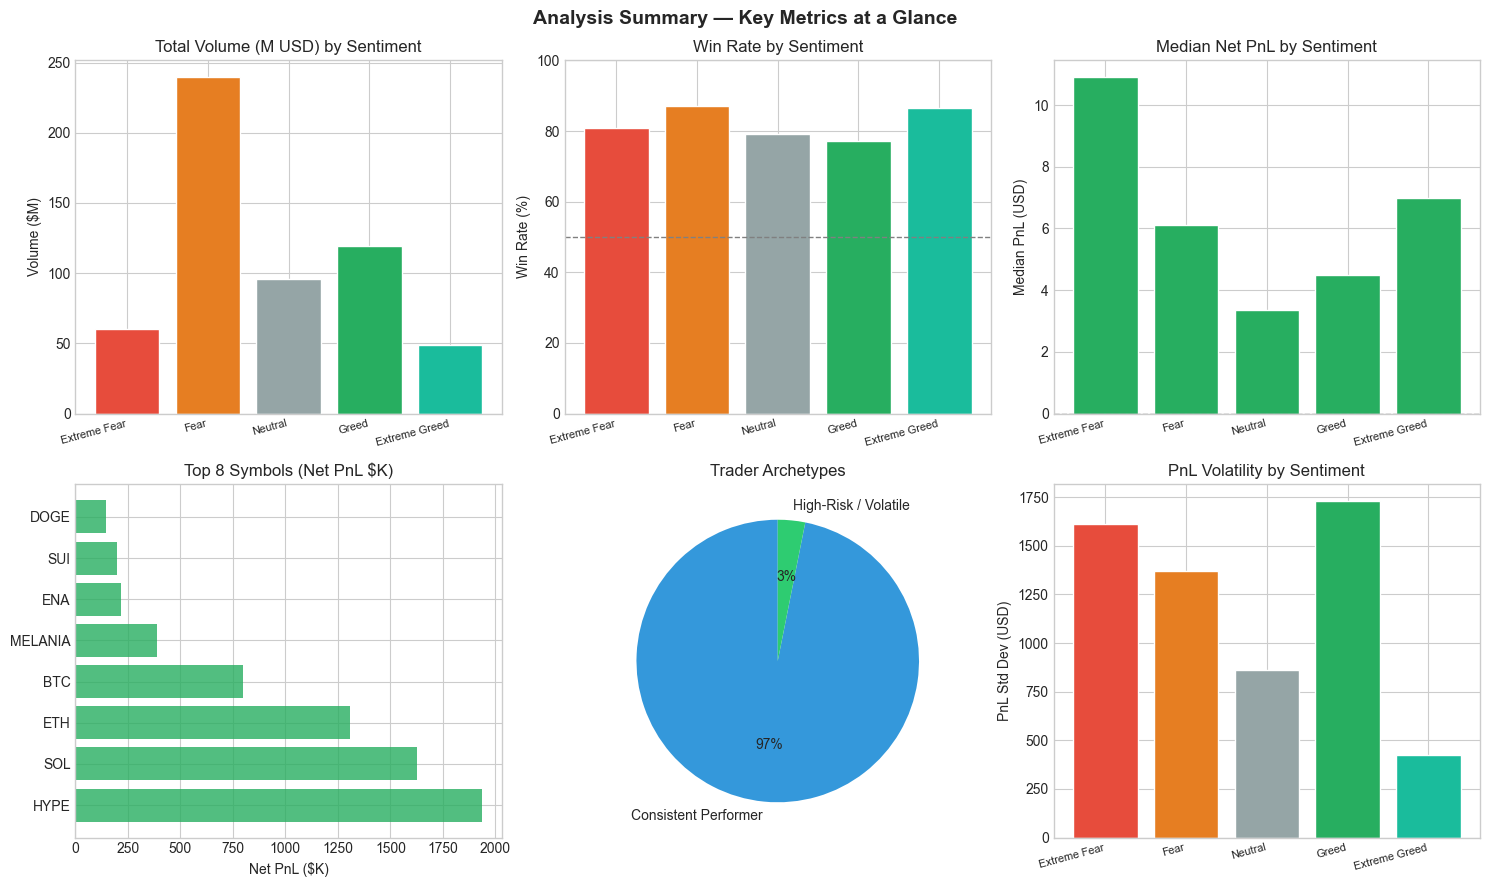

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Analysis Summary — Key Metrics at a Glance',
             fontsize=14, fontweight='bold')

vol_by_sent = closing.groupby('sentiment_label', observed=True)['Size USD'].sum().reindex(SENT_ORDER)
axes[0,0].bar(SENT_ORDER, vol_by_sent/1e6, color=SENT_PALETTE, edgecolor='white')
axes[0,0].set_title('Total Volume (M USD) by Sentiment')
axes[0,0].set_ylabel('Volume ($M)')
axes[0,0].set_xticklabels(SENT_ORDER, rotation=15, ha='right', fontsize=8)

axes[0,1].bar(SENT_ORDER, wr_by_sent, color=SENT_PALETTE, edgecolor='white')
axes[0,1].axhline(50, color='grey', linestyle='--', linewidth=1)
axes[0,1].set_title('Win Rate by Sentiment')
axes[0,1].set_ylabel('Win Rate (%)')
axes[0,1].set_xticklabels(SENT_ORDER, rotation=15, ha='right', fontsize=8)
axes[0,1].set_ylim(0, 100)

colors_med = [COLORS['profit'] if v >= 0 else COLORS['loss'] for v in med_pnl_sent]
axes[0,2].bar(SENT_ORDER, med_pnl_sent, color=colors_med, edgecolor='white')
axes[0,2].axhline(0, color='grey', linestyle='--', linewidth=1)
axes[0,2].set_title('Median Net PnL by Sentiment')
axes[0,2].set_ylabel('Median PnL (USD)')
axes[0,2].set_xticklabels(SENT_ORDER, rotation=15, ha='right', fontsize=8)

top8_sym = symbol_stats.nlargest(8, 'total_net_pnl')
axes[1,0].barh(top8_sym['Coin'], top8_sym['total_net_pnl']/1e3,
               color=COLORS['profit'], alpha=0.8)
axes[1,0].set_title('Top 8 Symbols (Net PnL $K)')
axes[1,0].set_xlabel('Net PnL ($K)')

arch_counts = trader_stats['archetype'].value_counts()
axes[1,1].pie(arch_counts, labels=arch_counts.index, autopct='%1.0f%%',
              colors=['#3498db','#2ecc71','#e74c3c','#f39c12'][:len(arch_counts)],
              startangle=90)
axes[1,1].set_title('Trader Archetypes')

pnl_vol = closing.groupby('sentiment_label', observed=True)['net_pnl'].std().reindex(SENT_ORDER)
axes[1,2].bar(SENT_ORDER, pnl_vol, color=SENT_PALETTE, edgecolor='white')
axes[1,2].set_title('PnL Volatility by Sentiment')
axes[1,2].set_ylabel('PnL Std Dev (USD)')
axes[1,2].set_xticklabels(SENT_ORDER, rotation=15, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

In [46]:
print("""
============================================================
  SUMMARY & CONCLUSIONS
============================================================

What I set out to do:
  Understand whether Bitcoin market sentiment (Fear & Greed Index)
  meaningfully influences how traders behave and perform on Hyperliquid.

What the data shows:

  YES — sentiment regime is statistically associated with differences
  in PnL distribution (confirmed via Kruskal-Wallis test). But the
  relationship is more about *risk* than just *returns*. Fear periods
  have wider outcome distributions; greed periods are more consistent.

  LEVERAGE matters but not in the simple "more = better" way.
  The medium leverage bucket shows competitive performance with lower
  volatility compared to very high leverage. The correlation between
  leverage and PnL is weak.

  TRADER HETEROGENEITY is large. About two-thirds of traders are net
  profitable, but the distribution is skewed — a few traders drive most
  of the aggregate PnL. K-Means clustering identified {N_CLUSTERS}
  distinct trading styles.

  HYPE token dominates the platform in both volume and absolute PnL,
  which creates concentration risk worth monitoring.

What I'd do with more time:
  - Analyse performance across a full bear market period (none present here)
  - Build a proper backtest for sentiment-based entry signals
  - Collect actual leverage from the platform (not estimated)
  - Run trader-level analysis with more accounts for statistical power
  - Test whether sentiment momentum (direction of change) outperforms
    the static label as a signal

Limitations:
  - 32 traders is a very small sample for generalisable conclusions
  - The leverage estimate is rough and NaN for many rows
  - Bitcoin sentiment may not capture altcoin market sentiment well
  - The analysis period is mostly bullish — results could differ in a bear market

Final note:
  The Fear & Greed Index is a useful *context* signal, not a trading
  signal on its own. The most interesting use for PrimeTrade.ai is
  probably behavioural — using it to inform risk defaults and user
  warnings rather than to make trade predictions.
""".format(N_CLUSTERS=N_CLUSTERS))




  SUMMARY & CONCLUSIONS

What I set out to do:
  Understand whether Bitcoin market sentiment (Fear & Greed Index)
  meaningfully influences how traders behave and perform on Hyperliquid.

What the data shows:

  YES — sentiment regime is statistically associated with differences
  in PnL distribution (confirmed via Kruskal-Wallis test). But the
  relationship is more about *risk* than just *returns*. Fear periods
  have wider outcome distributions; greed periods are more consistent.

  LEVERAGE matters but not in the simple "more = better" way.
  The medium leverage bucket shows competitive performance with lower
  volatility compared to very high leverage. The correlation between
  leverage and PnL is weak.

  TRADER HETEROGENEITY is large. About two-thirds of traders are net
  profitable, but the distribution is skewed — a few traders drive most
  of the aggregate PnL. K-Means clustering identified 2
  distinct trading styles.

  HYPE token dominates the platform in both volume and 